# Анализ статистики игроков

Исследуем индивидуальную статистику полевых игроков за сезон 2025/2026 и сравним показатели между основными игровыми позициями.

Основные вопросы анализа:
- как распределяются индивидуальные показатели игроков в течение сезона;
- чем отличаются профили `DEF`, `MID` и `ATT` по показателям на 90 минут;
- какие взаимосвязи наблюдаются между отдельными игровыми метриками.

In [136]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Подключение создано")

Подключение создано


In [137]:
with engine.connect() as connection:
    print("Подключение к PostgreSQL успешно")

Подключение к PostgreSQL успешно


## Данные

Для анализа используется `player_match_analysis`. Одна строка соответствует выступлению игрока в одном матче.

In [138]:
query = """
SELECT *
FROM player_match_analysis
"""

player = pd.read_sql(query, engine)


| Признак | Описание |
|---|---|
| `match_id` | ID матча |
| `season_id` | ID сезона |
| `starting_at` | Дата и время матча |
| `player_id` | ID игрока |
| `player_name` | Имя игрока |
| `team_id` | ID команды |
| `team_name` | Команда игрока |
| `home_away` | Дома / в гостях |
| `opponent_id` | ID соперника |
| `opponent_team_name` | Команда соперника |
| `team_goals` | Голы команды игрока |
| `opponent_goals` | Голы соперника |
| `result` | Результат команды: W/D/L |
| `points` | Очки за матч: 3/1/0 |
| `position_id` | ID позиции |
| `position_name` | Название позиции |
| `position_code` | Код позиции: GK/DEF/MID/ATT |
| `minutes_played` | Сыгранные минуты |
| `rating` | Оценка игрока Sportmonks |
| `touches` | Касания мяча |
| `possession_lost` | Потери владения |
| `goals` | Голы игрока |
| `assists` | Голевые передачи |
| `shots_total` | Всего ударов |
| `shots_on_target` | Удары в створ |
| `shots_off_target` | Удары мимо |
| `big_chances_created` | Созданные голевые моменты |
| `big_chances_missed` | Упущенные большие моменты |
| `key_passes` | Ключевые передачи |
| `chances_created` | Созданные моменты |
| `dribble_attempts` | Попытки обводки |
| `successful_dribbles` | Успешные обводки |
| `dribbled_past` | Игрока обыграли |
| `total_crosses` | Всего навесов |
| `accurate_crosses` | Точные навесы |
| `through_balls` | Проникающие передачи |
| `offsides` | Офсайды |
| `passes` | Всего передач |
| `accurate_passes` | Точные передачи |
| `long_balls` | Длинные передачи |
| `long_balls_won` | Выигранные длинные передачи |
| `passes_in_final_third` | Передачи в финальную треть |
| `backward_passes` | Передачи назад |
| `tackles` | Отборы |
| `tackles_won` | Выигранные отборы |
| `interceptions` | Перехваты |
| `clearances` | Выносы мяча |
| `total_duels` | Всего единоборств |
| `duels_won` | Выигранные единоборства |
| `duels_lost` | Проигранные единоборства |
| `aerials` | Воздушные единоборства |
| `aerials_won` | Выигранные верховые единоборства |
| `aerials_lost` | Проигранные верховые единоборства |
| `ball_recovery` | Возвраты владения |
| `dispossessed` | Потери мяча из-за отбора соперника |
| `fouls` | Совершённые фолы |
| `fouls_drawn` | Заработанные фолы |
| `yellowcards` | Жёлтые карточки |
| `redcards` | Красные карточки |
| `saves` | Сэйвы вратаря |
| `saves_insidebox` | Сэйвы внутри штрафной |
| `punches` | Отбивания кулаками |
| `good_high_claim` | Успешные выходы на верховые мячи |
| `goalkeeper_goals_conceded` | Пропущенные голы |
| `penalties_scored` | Забитые пенальти |
| `penalties_missed` | Незабитые пенальти |
| `penalties_won` | Заработанные пенальти |
| `penalties_committed` | Нарушения, приведшие к пенальти |
| `penalties_saved` | Отбитые пенальти |

## Подготовка данных

Сначала отделим вратарей от полевых игроков. Основной анализ ниже будет посвящён полевым игрокам.

In [139]:
goalkeepers = player[
    player['position_code'] == 'GK'
].copy()


In [140]:
outfield = player[
    player['position_code'] != 'GK'
].copy()

In [141]:
goalkeepers = goalkeepers.dropna(axis=1, how='all')
outfield = outfield.dropna(axis=1, how='all')

In [142]:
outfield.isna().mean().sort_values(ascending=False).head(30)

saves                  0.999697
penalties_missed       0.998029
redcards               0.994692
penalties_won          0.993024
penalties_scored       0.991811
penalties_committed    0.990143
through_balls          0.971641
assists                0.941159
goals                  0.914468
big_chances_missed     0.909463
offsides               0.897483
big_chances_created    0.893540
yellowcards            0.865635
accurate_crosses       0.772369
shots_on_target        0.763270
shots_off_target       0.738399
dribbled_past          0.686230
successful_dribbles    0.675311
chances_created        0.671671
aerials                0.614953
dispossessed           0.599788
interceptions          0.597361
key_passes             0.582651
tackles_won            0.570215
fouls_drawn            0.505611
shots_total            0.502123
total_crosses          0.492114
dribble_attempts       0.490143
fouls                  0.471641
long_balls_won         0.438277
dtype: float64

## Проверка качества данных

Перед расчётом производных показателей проверим несколько логических зависимостей в статистике `player_match`. 

In [143]:
count_cols = [
    'minutes_played', 'goals', 'assists', 'shots_total', 'shots_on_target',
    'dribble_attempts', 'successful_dribbles', 'passes', 'accurate_passes',
    'tackles', 'tackles_won', 'total_duels', 'duels_won', 'yellowcards',
    'redcards', 'saves'
]

quality_checks = {
    'Отрицательные значения в счётчиках': (outfield[count_cols] < 0).sum().sum(),
    'Удары в створ > всех ударов': (
        outfield['shots_on_target'] > outfield['shots_total']
    ).sum(),
    'Успешные обводки > попыток': (
        outfield['successful_dribbles'] > outfield['dribble_attempts']
    ).sum(),
    'Точные передачи > всех передач': (
        outfield['accurate_passes'] > outfield['passes']
    ).sum(),
    'Выигранные отборы > отборов': (
        outfield['tackles_won'] > outfield['tackles']
    ).sum(),
    'Выигранные единоборства > всех единоборств': (
        outfield['duels_won'] > outfield['total_duels']
    ).sum(),
    'Сэйвы у полевых игроков': (
        outfield['saves'].notna() & (outfield['saves'] != 0)
    ).sum()
}

pd.Series(quality_checks, name='Количество нарушений')

Отрицательные значения в счётчиках             0
Удары в створ > всех ударов                    0
Успешные обводки > попыток                     3
Точные передачи > всех передач                 1
Выигранные отборы > отборов                   79
Выигранные единоборства > всех единоборств     1
Сэйвы у полевых игроков                        2
Name: Количество нарушений, dtype: int64

По результатам проверки обнаружены отдельные нарушения логических зависимостей в исходных данных. Строки не удаляются и значения не корректируются автоматически, поскольку такие изменения потребовали бы предположений о правильном значении показателя. Аномалии рассматриваются как ограничение качества исходных данных.

In [144]:
outfield = outfield.drop(columns='saves')

Проверим пропуски и подготовим числовые показатели для расчётов. Метрики, которые не применяются к конкретному игроку, представлены пропусками; для расчётов счётчиков они заменяются на нули.

In [145]:
numeric_cols = outfield.select_dtypes(
    include=['int64', 'float64']
).columns

numeric_cols = numeric_cols.drop('rating', errors='ignore')

outfield[numeric_cols] = outfield[numeric_cols].fillna(0)

In [146]:
numeric_cols_gk = goalkeepers.select_dtypes(
    include=['int64', 'float64']
).columns

numeric_cols_gk = numeric_cols_gk.drop('rating', errors='ignore')

goalkeepers[numeric_cols_gk] = goalkeepers[numeric_cols_gk].fillna(0)

In [147]:
outfield['minutes_played'].describe()

count    6594.000000
mean       62.126782
std        31.316520
min         1.000000
25%        29.000000
50%        76.000000
75%        90.000000
max        90.000000
Name: minutes_played, dtype: float64

## Игровое время

Посмотрим на распределение игрового времени игроков перед расчётом сезонных показателей.

<Axes: xlabel='minutes_played', ylabel='Count'>

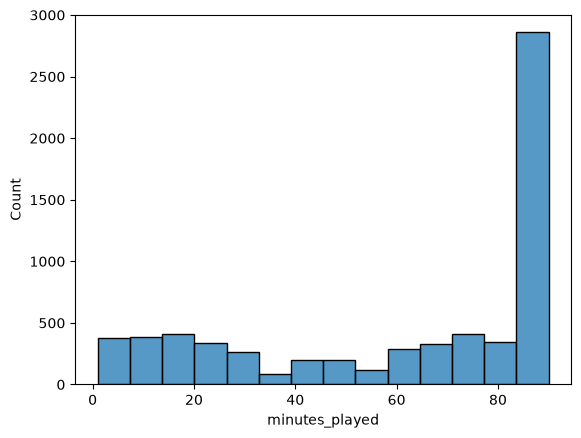

In [148]:
sns.histplot(outfield['minutes_played'])

Посмотрим, сколько игроков использовала каждая команда.

In [149]:
outfield.groupby('team_name')['player_id'].nunique().sort_values(ascending=False)

team_name
Aberdeen         35
Rangers          35
Livingston       35
Celtic           33
St. Mirren       29
Kilmarnock       29
Falkirk          29
Hibernian        29
Dundee United    28
Dundee           27
Hearts           26
Motherwell       26
Name: player_id, dtype: int64

## Эффективность действий

Рассчитаем несколько показателей эффективности: точность передач, ударов, дриблинга, отборов и единоборств.

In [150]:
def safe_ratio(numerator, denominator):
    return (
        numerator.div(denominator)
        .where(denominator != 0)
        * 100
    )

In [151]:
outfield['pass_accuracy'] = safe_ratio(
    outfield['accurate_passes'],
    outfield['passes']
)

outfield['shot_accuracy'] = safe_ratio(
    outfield['shots_on_target'],
    outfield['shots_total']
)

outfield['dribble_success'] = safe_ratio(
    outfield['successful_dribbles'],
    outfield['dribble_attempts']
)

outfield['duel_success'] = safe_ratio(
    outfield['duels_won'],
    outfield['total_duels']
)

## Команда и позиция игрока

Некоторые игроки по ходу сезона могли выступать за разные команды или на разных позициях. Для итоговой таблицы выберем основную команду и позицию по максимальному количеству сыгранных матчей. При равенстве используется большее суммарное игровое время.

В рамках анализа одного сезона `player_name` используется как ключ игрока, поскольку в рассматриваемом наборе данных каждому имени соответствует один игрок. Это позволяет сохранить читаемую структуру итоговых таблиц и группировок.

При этом сезонные показатели игрока рассчитываются по всем его матчам за сезон. Выбранные команда и позиция используются прежде всего для классификации и последующего сравнения игроков.

In [152]:
trimmed = outfield[
    ['player_name', 'team_name', 'position_code']
].drop_duplicates()

In [153]:
dubl_info = trimmed.groupby('player_name')[['team_name', 'position_code']].nunique()


In [154]:
dubl_info[
    (dubl_info['team_name'] > 1) | (dubl_info['position_code'] > 1) 
    ].sort_values('team_name', ascending=False)

,team_name,position_code
player_name,,
Stephen Welsh,2,1
Findlay Curtis,2,3
Lyall Cameron,2,2
Scott Arfield,2,1
Alexandros Gogić,1,2
...,...,...
Tyreece John-Jules,1,2
Vicko Ševelj,1,2
Will Ferry,1,2


In [155]:
team_per_player = (
    outfield
    .groupby(['player_name', 'team_name'])
    .agg(
        matches=('match_id', 'nunique'),
        minutes=('minutes_played', 'sum')
    )
    .reset_index()
    .sort_values(
        ['player_name', 'matches', 'minutes'],
        ascending=[True, False, False]
    )
    .drop_duplicates('player_name')
)

In [156]:
position_per_player = (
    outfield
    .groupby(['player_name', 'position_code'])
    .agg(
        matches=('match_id', 'nunique'),
        minutes=('minutes_played', 'sum')
    )
    .reset_index()
    .sort_values(
        ['player_name', 'matches', 'minutes'],
        ascending=[True, False, False]
    )
    .drop_duplicates('player_name')
)

## Статистика игроков за сезон

Агрегируем матчевую статистику на уровень игрока за сезон.

In [157]:
sum_cols = [
    'minutes_played', 'goals', 'assists',
    'touches', 'possession_lost',
    'shots_total', 'shots_on_target', 'shots_off_target',
    'big_chances_created', 'big_chances_missed', 'key_passes', 'chances_created',
    'dribble_attempts', 'successful_dribbles', 'dribbled_past',
    'total_crosses', 'accurate_crosses', 'through_balls', 'offsides',
    'passes', 'accurate_passes', 'long_balls', 'long_balls_won',
    'passes_in_final_third', 'backward_passes',
    'tackles', 'interceptions', 'clearances',
    'total_duels', 'duels_won', 'duels_lost',
    'aerials', 'aerials_won', 'aerials_lost',
    'ball_recovery', 'dispossessed', 'fouls', 'fouls_drawn',
    'yellowcards', 'redcards', 'penalties_committed'
]

In [158]:
player_season = (
    outfield
    .groupby('player_name')[sum_cols]
    .sum()
    .reset_index()
    .rename(columns={'minutes_played': 'minutes'})
)

matches = (
    outfield.groupby('player_name')['match_id']
    .nunique()
    .rename('matches')
    .reset_index()
)

player_season = player_season.merge(matches, on='player_name')

In [159]:
season_means = (
    outfield
    .groupby('player_name')[[
        'rating',
        'pass_accuracy',
        'shot_accuracy',
        'dribble_success',
            'duel_success'
    ]]
    .mean()
    .reset_index()
)

player_season = player_season.merge(season_means, on='player_name')

In [160]:
player_season = (
    player_season
    .merge(team_per_player[['player_name', 'team_name']], on='player_name')
    .merge(position_per_player[['player_name', 'position_code']], on='player_name')
)

### Результативность

Посмотрим на индивидуальные голы, ассисты и суммарный вклад `G+A`.

In [161]:
player_season[['player_name', 'team_name', 'goals']].sort_values('goals', ascending=False).head(10)

,player_name,team_name,goals
328,Tawanda Jethro Maswanhise,Motherwell,17.0
40,Benjamin Nygren,Celtic,16.0
216,Lawrence Shankland,Hearts,16.0
350,Youssef Ramalho Chermiti,Rangers,15.0
71,Cláudio Rafael Soares Braga,Hearts,14.0
81,Daizen Maeda,Celtic,14.0
202,Kevin Nisbet,Aberdeen,9.0
353,Zachary Sapsford,Dundee United,9.0
20,Amar Abdirahman Ahmed Fatah,Dundee United,8.0
250,Mbule Longelo Emmanuel,Motherwell,8.0


In [162]:
player_season[['player_name', 'team_name', 'assists']].sort_values('assists', ascending=False).head(10)

,player_name,team_name,assists
58,Calvin Miller,Falkirk,9.0
57,Callum Slattery,Motherwell,8.0
204,Kieran Tierney,Celtic,8.0
15,Alexandros Kiziridis,Hearts,8.0
60,Cameron Congreve,Dundee,7.0
107,Elijah Henry Just,Motherwell,7.0
140,Greg Kiltie,Kilmarnock,7.0
270,Nicolas Raskin,Rangers,7.0
81,Daizen Maeda,Celtic,6.0
348,Will Ferry,Dundee United,6.0


In [163]:
player_season['g+a'] = player_season['goals'] + player_season['assists']

In [164]:
player_season[['player_name', 'team_name', 'g+a']].sort_values('g+a', ascending=False).head(10)

,player_name,team_name,g+a
40,Benjamin Nygren,Celtic,21.0
81,Daizen Maeda,Celtic,20.0
350,Youssef Ramalho Chermiti,Rangers,20.0
328,Tawanda Jethro Maswanhise,Motherwell,19.0
216,Lawrence Shankland,Hearts,19.0
71,Cláudio Rafael Soares Braga,Hearts,17.0
58,Calvin Miller,Falkirk,16.0
204,Kieran Tierney,Celtic,14.0
107,Elijah Henry Just,Motherwell,14.0
270,Nicolas Raskin,Rangers,13.0


## Дисциплина

Посмотрим на распределение жёлтых и красных карточек среди игроков и команд.

In [165]:
player_season.groupby('team_name')[['yellowcards', 'redcards']].sum().reset_index().sort_values('yellowcards', ascending=False)

,team_name,yellowcards,redcards
0,Aberdeen,86.0,5.0
8,Livingston,86.0,4.0
7,Kilmarnock,83.0,4.0
3,Dundee United,81.0,3.0
4,Falkirk,80.0,1.0
1,Celtic,75.0,2.0
6,Hibernian,72.0,3.0
5,Hearts,71.0,3.0
11,St. Mirren,71.0,4.0
10,Rangers,71.0,1.0


Здесь учитываются карточки игроков из `player_match_analysis`, поэтому показатель не обязан совпадать с командной статистикой из предыдущего анализа.

In [166]:
player_season[['player_name', 'team_name', 'yellowcards', 'redcards']].sort_values('yellowcards', ascending=False).head(10)

,player_name,team_name,yellowcards,redcards
288,Robbie Deas,Kilmarnock,13.0,0.0
47,Brad Spencer,Falkirk,13.0,0.0
227,Liam Scales,Celtic,12.0,0.0
14,Alexandros Gogić,St. Mirren,12.0,1.0
104,Dylan Tait,Falkirk,10.0,0.0
149,Iurie Iovu,Dundee United,10.0,0.0
78,Craig Halkett,Hearts,9.0,1.0
55,Callum McGregor,Celtic,9.0,0.0
48,Bradley Lyons,Kilmarnock,9.0,0.0
118,Ethan Hamilton,Dundee,9.0,0.0


## Игровое время и показатели на 90 минут

Для сравнения игроков с разным количеством игрового времени переведём счётчики в показатели на 90 минут.

<Axes: ylabel='minutes'>

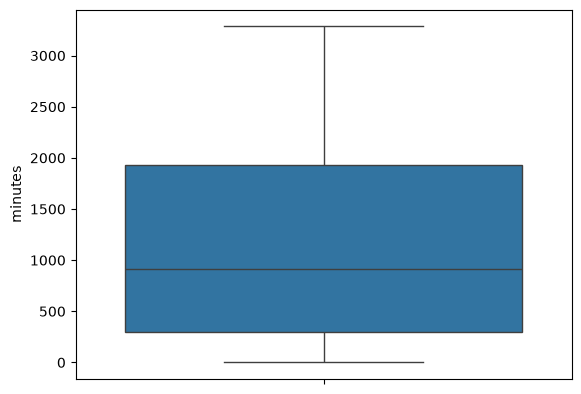

In [167]:
sns.boxplot(player_season['minutes'])

<Axes: xlabel='minutes', ylabel='Count'>

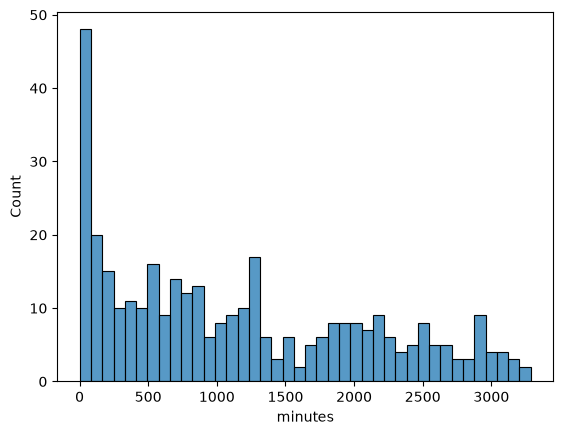

In [168]:
sns.histplot(player_season['minutes'], bins = 40)

Перед расчётом `per90` оставим игроков с достаточным объёмом игрового времени. Используем порог 360 минут — это эквивалент четырём полным матчам. Порог снижает влияние крайне малой выборки на показатели на 90 минут, хотя не исключает статистическую нестабильность полностью.

In [169]:
id_cols = [
    'player_name',
    'team_name',
    'position_code',
    'matches',
    'minutes',
    'rating'
]

efficiency_cols = [
    'pass_accuracy',
    'shot_accuracy',
    'dribble_success',
    'duel_success'
]

In [170]:
per90_cols = [
    'goals',
    'assists',
    'shots_total',
    'shots_on_target',
    'passes',
    'passes_in_final_third',
    'long_balls',
    'key_passes',
    'chances_created',
    'big_chances_created',
    'tackles',
    'interceptions',
    'clearances',
    'duels_won',
    'dribble_attempts',
    'successful_dribbles',
    'dispossessed'
]

In [171]:
player_season_per90 = player_season[
    player_season['minutes'] >= 360
][id_cols + efficiency_cols].copy()

In [172]:
for col in per90_cols:
    player_season_per90[f'{col}_per90'] = (
        player_season[col]
        / player_season['minutes']
        * 90
    )

### Показатели на 90 минут

Сравним несколько основных показателей после нормировки на игровое время.

In [173]:
player_season_per90[['player_name', 'team_name', 'goals_per90', 'minutes']].sort_values(
    'goals_per90', ascending=False).head(10)

,player_name,team_name,goals_per90,minutes
200,Kelechi Promise Iheanacho,Celtic,0.920245,489
26,Ante Šuto,Hibernian,0.843091,427
350,Youssef Ramalho Chermiti,Rangers,0.684584,1972
106,Elie Youan,Hibernian,0.681818,660
172,Joe Hugill,Kilmarnock,0.659945,1091
344,Tyreece John-Jules,Kilmarnock,0.625543,1151
91,David Junior Hoilett,Hibernian,0.619266,436
28,Apostolos Stamatelopoulos,Motherwell,0.608108,888
216,Lawrence Shankland,Hearts,0.579011,2487
40,Benjamin Nygren,Celtic,0.566483,2542


In [174]:
player_season_per90[['player_name', 'team_name', 'assists_per90', 'minutes']].sort_values(
    'assists_per90', ascending=False).head(10)

,player_name,team_name,assists_per90,minutes
21,Andreas Skov Olsen,Rangers,0.540000,500
65,Charlie Reilly,Dundee,0.476190,378
312,Scott Tanser,St. Mirren,0.415704,866
274,Oliver Antman,Rangers,0.387931,696
186,Josh Campbell,Hibernian,0.379747,711
181,Jon Nouble,Livingston,0.323741,556
57,Callum Slattery,Motherwell,0.309677,2325
72,Colby Donovan,Celtic,0.290792,619
204,Kieran Tierney,Celtic,0.283576,2539
58,Calvin Miller,Falkirk,0.279022,2903


In [175]:
player_season_per90[
    ['player_name', 'team_name', 'position_code', 'shots_total_per90', 'minutes']
    ].sort_values('shots_total_per90', ascending=False).head(10)

,player_name,team_name,position_code,shots_total_per90,minutes
179,Johnny Kenny,Celtic,ATT,5.101744,688
200,Kelechi Promise Iheanacho,Celtic,ATT,4.049080,489
91,David Junior Hoilett,Hibernian,ATT,3.922018,436
344,Tyreece John-Jules,Kilmarnock,ATT,3.675065,1151
127,Findlay Curtis,Kilmarnock,MID,3.614173,1270
350,Youssef Ramalho Chermiti,Rangers,ATT,3.559838,1972
170,Jesper Karlsson,Aberdeen,ATT,3.485670,1291
106,Elie Youan,Hibernian,ATT,3.409091,660
337,Tomáš Čvančara,Celtic,ATT,3.409091,528
150,Ivan Dolček,Dundee United,ATT,3.303571,1008


In [176]:
player_season_per90[['player_name', 'team_name', 'position_code', 'passes_per90', 'minutes']].sort_values(
    'passes_per90', ascending=False).head(10)

,player_name,team_name,position_code,passes_per90,minutes
59,Cameron Carter-Vickers,Celtic,DEF,97.857143,630
227,Liam Scales,Celtic,DEF,86.920594,3098
108,Elliot Watt,Motherwell,MID,85.037905,2902
32,Auston Trusty,Celtic,DEF,83.339500,2162
27,Anthony Ralston,Celtic,DEF,76.292308,1300
83,Dane Murray,Celtic,DEF,74.813896,403
240,Marcelo Josemir Saracchi Pintos,Celtic,DEF,74.524887,663
95,Derek Cornelius,Rangers,DEF,71.806798,559
55,Callum McGregor,Celtic,MID,69.899906,3197
323,Stephen O'Donnell,Motherwell,DEF,67.902708,2179


In [177]:
player_season_per90.groupby('position_code').agg(
    passes=('passes_per90', 'median'),
    passes_accuracy=('pass_accuracy', 'mean')
)

,passes,passes_accuracy
position_code,,
ATT,19.464286,69.191672
DEF,42.429737,78.966983
MID,35.599905,77.516841


### Вывод по общему блоку per90

Нормализация показателей на 90 минут позволяет сопоставлять игроков с разным игровым временем и перейти от простых сезонных сумм к интенсивности действий. В дальнейшем эти показатели используются для сравнения профилей игроков по позициям.

## Сравнение игроков по позициям

Разделим игроков на `DEF`, `MID` и `ATT` и отдельно посмотрим статистику каждой группы.

In [178]:
midfielders = player_season_per90[
    player_season_per90['position_code'] == 'MID'
    ].copy()

attackers = player_season_per90[
    player_season_per90['position_code'] == 'ATT'
    ].copy()

defenders = player_season_per90[
    player_season_per90['position_code'] == 'DEF'
    ].copy()

### Защитники

Для защитников рассмотрим оборонительные действия и показатели работы с мячом.

In [179]:
defender_metrics = [
    'tackles_per90',
    'interceptions_per90',
    'duels_won_per90',
    'clearances_per90',
    'passes_per90',
    'pass_accuracy',
    'long_balls_per90'
]

#### Оборонительные показатели: отборы, перехваты, выигранные единоборства и выносы.

In [180]:
defenders[defender_metrics].describe()

,tackles_per90,interceptions_per90,duels_won_per90,clearances_per90,passes_per90,pass_accuracy,long_balls_per90
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
mean,1.697469,1.124180,5.464176,5.332955,46.465492,78.966983,5.870798
std,0.720149,0.366002,1.458822,1.992619,14.551840,6.586201,1.969609
min,0.422866,0.446872,3.032915,1.505376,20.607477,61.781832,2.313084
25%,1.176068,0.860062,4.508903,3.500033,37.073142,74.299211,4.743788
50%,1.534789,1.091791,5.420168,5.383436,42.429737,78.960496,5.797546
75%,2.103969,1.357632,6.277757,6.947328,53.233361,83.744783,7.003513
max,4.750733,2.118959,9.602978,9.192399,97.857143,95.152750,13.320937


In [181]:
defenders[defender_metrics].corr()

,tackles_per90,interceptions_per90,duels_won_per90,clearances_per90,passes_per90,pass_accuracy,long_balls_per90
tackles_per90,1.000000,0.049661,0.401924,-0.421310,-0.217344,-0.250289,-0.217232
interceptions_per90,0.049661,1.000000,0.113097,0.079548,-0.179631,-0.099178,-0.205988
duels_won_per90,0.401924,0.113097,1.000000,0.273813,0.116075,-0.112457,0.019268
clearances_per90,-0.421310,0.079548,0.273813,1.000000,0.093565,0.027428,0.404814
passes_per90,-0.217344,-0.179631,0.116075,0.093565,1.000000,0.655391,0.186011
pass_accuracy,-0.250289,-0.099178,-0.112457,0.027428,0.655391,1.000000,-0.181363
long_balls_per90,-0.217232,-0.205988,0.019268,0.404814,0.186011,-0.181363,1.000000


<Axes: ylabel='tackles_per90'>

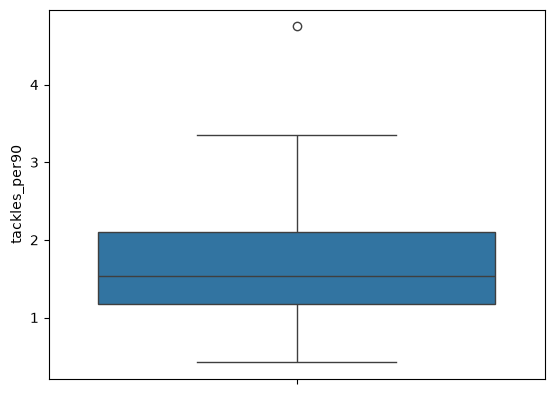

In [183]:
sns.boxplot(defenders['tackles_per90'])

<Axes: ylabel='interceptions_per90'>

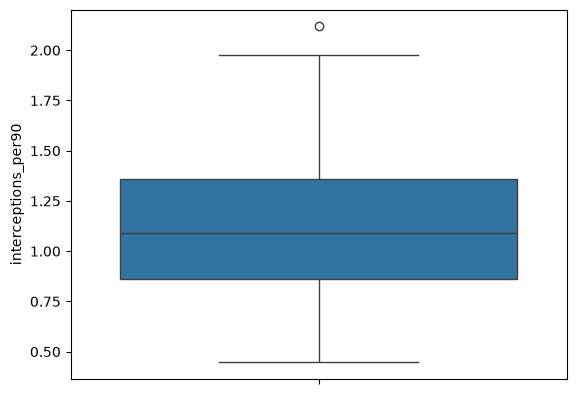

In [185]:
sns.boxplot(defenders['interceptions_per90'])

<Axes: ylabel='duels_won_per90'>

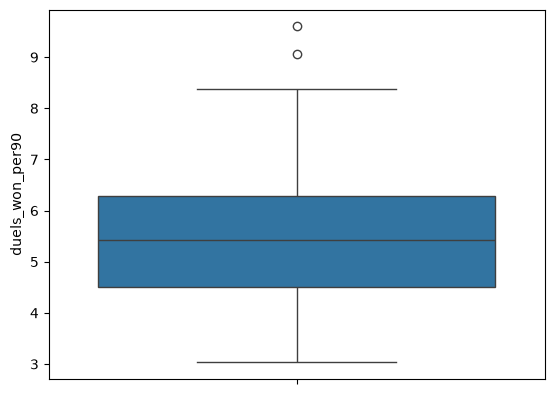

In [187]:
sns.boxplot(defenders['duels_won_per90'])

<Axes: ylabel='clearances_per90'>

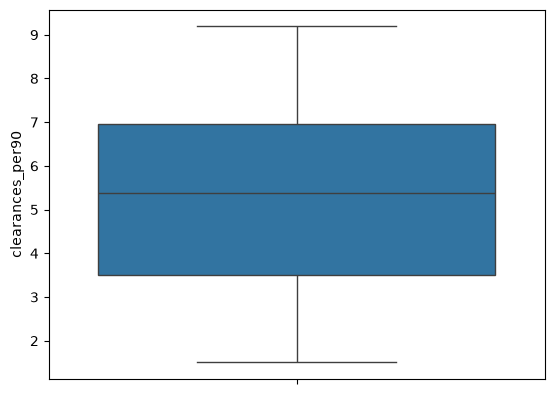

In [189]:
sns.boxplot(defenders['clearances_per90'])

Распределения метрик показывают заметную вариативность между защитниками.

Для **отборов** среднее значение составляет 1.70 на 90 минут, медиана — 1.53. Большинство наблюдений находится примерно в диапазоне от 1.18 до 2.10, при этом максимальное значение достигает 4.75.

Для **перехватов** среднее и медианное значения близки — 1.12 и 1.09 соответственно. Основная часть игроков находится в диапазоне 0.86–1.36 перехвата за 90 минут.

По **выигранным единоборствам** среднее значение составляет 5.46, а медиана — 5.42. Распределение относительно сосредоточено в центральной части, хотя отдельные игроки заметно выделяются по этому показателю.

**Выносы** характеризуются более широким разбросом: среднее значение — 5.33, медиана — 5.38, а диапазон составляет от 1.51 до 9.19.

В целом защитники заметно различаются по профилю действий: одни чаще вступают в отборы и единоборства, другие имеют более высокие показатели выносов или объёма работы с мячом.

<Axes: >

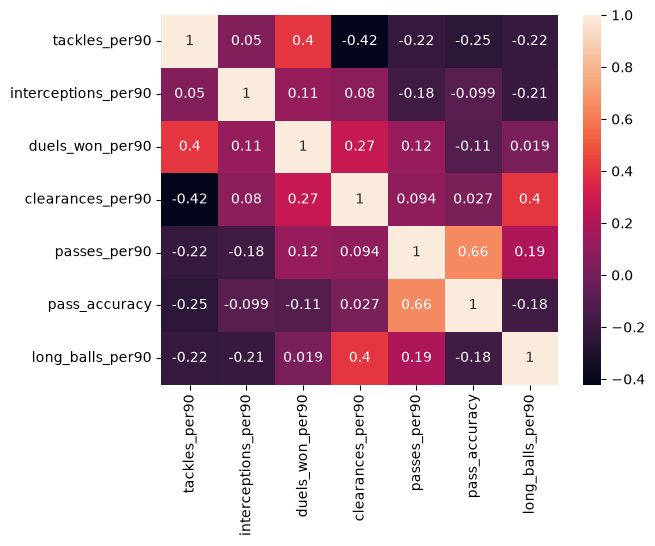

In [182]:
sns.heatmap(defenders[defender_metrics].corr(), annot=True)

Корреляционный анализ показывает, что большинство защитных метрик имеют слабую или умеренную взаимосвязь между собой.

Наиболее заметная положительная корреляция наблюдается между **отборами и выигранными единоборствами** (`r = 0.40`). Это означает, что в данной выборке более высокие значения одного показателя в некоторой степени связаны с более высокими значениями другого.

Между **отборами и выносами** наблюдается умеренная отрицательная корреляция (`r = -0.42`). При этом корреляция не означает причинно-следственную связь: показатели могут отражать разные игровые модели и роль защитника в команде.

Отдельно выделяется связь между **количеством передач и точностью передач** (`r = 0.66`). В рассматриваемой выборке защитники, выполняющие больше передач за 90 минут, в среднем также имеют более высокую точность передач.

Остальные взаимосвязи преимущественно слабые, поэтому метрики в значительной степени характеризуют разные стороны игры защитников.

In [184]:
defenders[
    ['player_name', 'tackles_per90']
    ].sort_values('tackles_per90', ascending=False).head(10)

,player_name,tackles_per90
162,Jamie Brandon,4.750733
188,Joshua Brenet,3.355932
305,Sam Hart,3.247423
46,Brad Halliday,3.066667
126,Filip Lissah,3.001316
2,Adam Montgomery,2.898773
149,Iurie Iovu,2.717584
198,Keelan Adams,2.625384
72,Colby Donovan,2.617124
312,Scott Tanser,2.598152


In [186]:
defenders[
    ['player_name', 'interceptions_per90']
    ].sort_values('interceptions_per90', ascending=False).head(10)

,player_name,interceptions_per90
259,Mitchel Frame,2.118959
62,Cammy Kerr,1.975309
149,Iurie Iovu,1.958259
212,Krisztián Keresztes,1.871102
305,Sam Hart,1.855670
146,Imari Narain Samuels,1.762178
185,Jordi Altena,1.724739
42,Bert Esselink,1.709559
263,Nasser Yacouba Djiga,1.615385
126,Filip Lissah,1.579640


In [188]:
defenders[['player_name', 'duels_won_per90']].sort_values('duels_won_per90', ascending=False).head(10)

,player_name,duels_won_per90
83,Dane Murray,9.602978
73,Coll Donaldson,9.067164
141,Harry Milne,8.376309
305,Sam Hart,8.350515
126,Filip Lissah,8.293111
95,Derek Cornelius,8.211091
233,Luke Graham,7.938639
162,Jamie Brandon,7.785924
43,Billy Koumetio,7.553444
78,Craig Halkett,7.523659


In [190]:
defenders[
    ['player_name', 'clearances_per90']
    ].sort_values('clearances_per90', ascending=False).head(10)

,player_name,clearances_per90
43,Billy Koumetio,9.192399
73,Coll Donaldson,9.067164
132,Frankie Kent,8.661088
295,Ross Graham,8.634868
212,Krisztián Keresztes,8.513514
50,Brooklyn Kabongolo,8.475000
78,Craig Halkett,8.162461
225,Liam Morrison,7.914778
117,Ethan Brown,7.785924
308,Samuel Cleall-Harding,7.698289




Для сравнения игроков были рассмотрены лидеры по основным защитным показателям. Результаты показывают, что лидеры по разным метрикам в значительной степени не совпадают.

Jamie Brandon значительно выделяется по количеству отборов — 4.75 за 90 минут, что заметно выше следующего результата (3.36). Это может указывать на более выраженную роль в непосредственном отборе мяча.

По перехватам лидируют Iurie Iovu (1.96) и Krisztián Keresztes (1.87), тогда как по выигранным единоборствам лидерами являются Dane Murray (9.60) и Coll Donaldson (9.07). Таким образом, высокая эффективность защитника в одном типе оборонительных действий не обязательно сопровождается аналогичным результатом в другом.

При этом Sam Hart входит в число лидеров сразу по трём показателям: отборам, перехватам и выигранным единоборствам. Это выделяет его не просто как игрока с высоким значением одной отдельной метрики, а как защитника с высокими показателями сразу в нескольких компонентах оборонительной игры.

По выносам картина отличается: лидируют Billy Koumetio (9.19), Coll Donaldson (9.07), Frankie Kent (8.66) и Ross Graham (8.63). Высокие значения этой метрики характеризуют другой тип оборонительной активности, поэтому прямое сравнение таких игроков только по одному показателю может быть некорректным.

Таким образом, анализ лидеров показывает, что **защитную игру нельзя полноценно описать одной метрикой**. Разные показатели выделяют разных игроков, а отдельные футболисты, такие как Sam Hart и Coll Donaldson, проявляют высокие результаты сразу в нескольких компонентах. Это является основанием для дальнейшего сравнения защитников уже по совокупности метрик, а не по отдельным рейтингам.

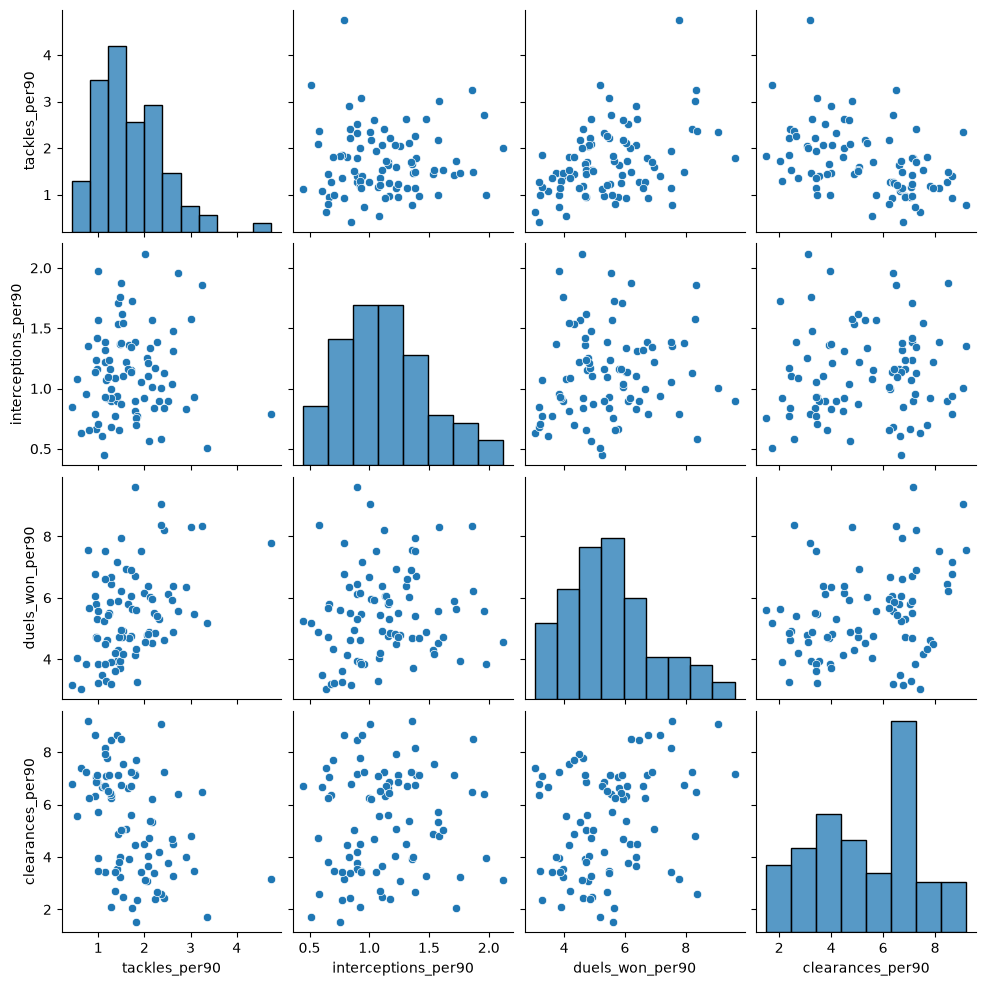

In [191]:
sns.pairplot(defenders[defender_metrics[:4]])

PairPlot позволяет одновременно оценить распределения отдельных метрик и характер взаимосвязей между ними.

Визуально наиболее заметны несколько закономерностей, выявленных и корреляционным анализом. Между **отборами и выигранными единоборствами** прослеживается положительная зависимость, тогда как между **отборами и выносами** наблюдается отрицательная тенденция.

Также заметна связь между **объёмом передач и точностью передач**, которая является наиболее выраженной среди рассмотренных показателей.

При этом значительная часть точек остаётся достаточно рассеянной, что подтверждает отсутствие сильной линейной зависимости между большинством защитных метрик. Это указывает на различия в игровых профилях защитников и показывает, что оценивать их только по одному показателю недостаточно.

#### Показатели работы с мячом: передачи, точность передач и длинные передачи.

<Axes: ylabel='passes_per90'>

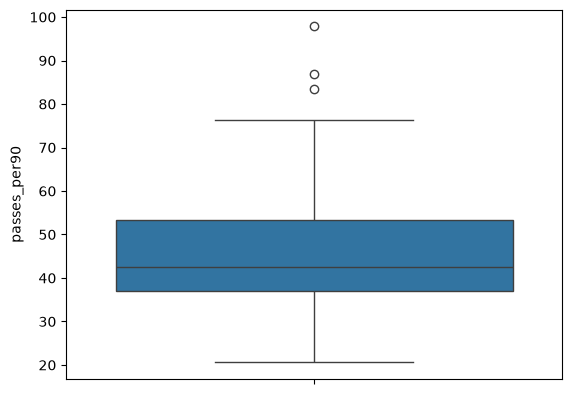

In [192]:
sns.boxplot(defenders['passes_per90'])

<Axes: ylabel='pass_accuracy'>

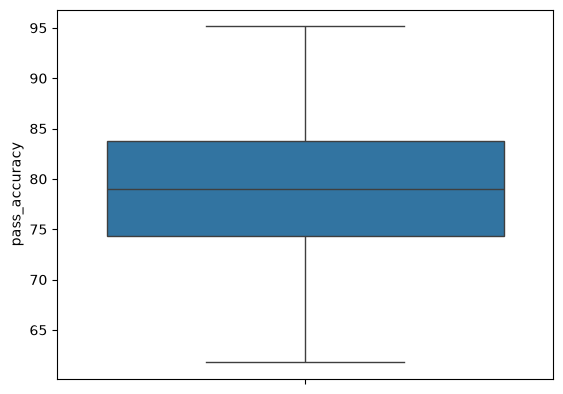

In [195]:
sns.boxplot(defenders['pass_accuracy'])

<Axes: ylabel='long_balls_per90'>

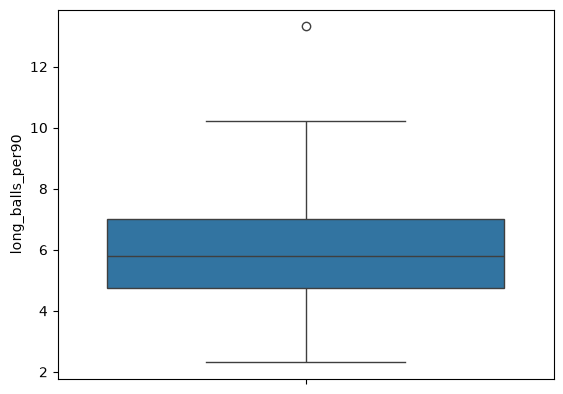

In [197]:
sns.boxplot(defenders['long_balls_per90'])

Показатели передач демонстрируют различную степень вариативности между защитниками.

Среднее количество **передач за 90 минут** составляет 46.47, медиана — 42.43. При этом разброс достаточно большой: значения находятся в диапазоне от 20.61 до 97.86 передач за 90 минут. Это указывает на заметные различия в объёме участия защитников в розыгрыше мяча.

**Точность передач** имеет значительно более компактное распределение: среднее значение составляет 78.97%, медиана — 78.96%, а значения находятся в диапазоне от 61.78% до 95.15%. Практически совпадающие среднее и медианное значения показывают, что распределение этого показателя относительно симметрично.

Для **длинных передач за 90 минут** среднее значение составляет 5.87, медиана — 5.80. Значения варьируются от 2.31 до 13.32, поэтому между защитниками также существуют заметные различия в использовании длинных передач.

Таким образом, наиболее сильно между защитниками различается **объём передач**, тогда как точность передач распределена более компактно. При этом показатели длинных передач позволяют дополнительно различать стиль игры защитников при продвижении мяча.

In [193]:
defenders[
    ['player_name' , 'passes_per90']
].sort_values('passes_per90', ascending=False).head(10)

,player_name,passes_per90
59,Cameron Carter-Vickers,97.857143
227,Liam Scales,86.920594
32,Auston Trusty,83.339500
27,Anthony Ralston,76.292308
83,Dane Murray,74.813896
240,Marcelo Josemir Saracchi Pintos,74.524887
95,Derek Cornelius,71.806798
323,Stephen O'Donnell,67.902708
281,Paul McGinn,66.110340
178,John Souttar,65.511420


In [196]:
defenders[
    ['player_name' , 'pass_accuracy']
].sort_values('pass_accuracy', ascending=False).head(10)

,player_name,pass_accuracy
59,Cameron Carter-Vickers,95.152750
32,Auston Trusty,91.304662
227,Liam Scales,90.742514
263,Nasser Yacouba Djiga,89.444275
281,Paul McGinn,89.434433
324,Stephen Welsh,89.037973
178,John Souttar,88.981574
132,Frankie Kent,88.882909
139,Grant Hanley,88.508835
291,Rocky Bushiri,88.507287


In [198]:
defenders[
    ['player_name' , 'long_balls_per90']
].sort_values('long_balls_per90', ascending=False).head(10)

,player_name,long_balls_per90
88,Danny Wilson,13.320937
287,Richard King,10.222110
164,Jamie Mccart,9.511041
73,Coll Donaldson,9.402985
219,Lewis Mayo,9.387417
255,Miguel Freckleton,8.627511
288,Robbie Deas,8.593400
151,Jack Iredale,8.401361
220,Lewis Neilson,8.316366
42,Bert Esselink,8.216912


По объёму передач заметно выделяется Cameron Carter-Vickers — 97.9 передачи за 90 минут. Он же занимает первое место по точности передач (95.2%), поэтому в его случае высокий объём работы с мячом сочетается с очень высокой надёжностью передач. Также высокие значения по объёму передач имеют Liam Scales и Auston Trusty.

Интересно, что среди лидеров по точности передач также находятся Nasser Yacouba Djiga, Paul McGinn и Stephen Welsh. При этом их объём передач не настолько высок, как у лидеров по passes_per90. То есть высокая точность сама по себе не означает большого количества передач.

По длинным передачам картина совсем другая. Здесь лидирует Danny Wilson — 13.3 передачи за 90 минут, заметно опережая Richard King (10.2) и Jamie Mccart (9.5). Эти игроки выделяются именно использованием длинных передач, а не обязательно общим объёмом пасовой работы.

В целом по топам можно увидеть разные стили игры защитников: одни много участвуют в розыгрыше мяча и при этом сохраняют высокую точность, другие делают акцент на длинных передачах.

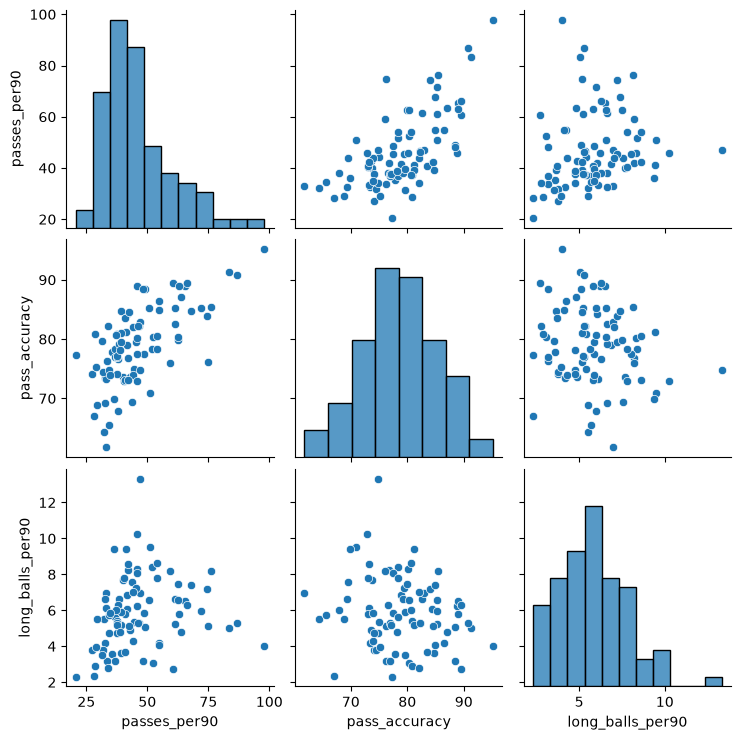

In [199]:
sns.pairplot(defenders[defender_metrics[4:]])

На PairPlot хорошо видно, что **количество передач и их точность связаны между собой**. Корреляция между ними составляет 0.66 — это самая сильная связь среди трёх рассмотренных показателей. В этой выборке защитники, которые чаще участвуют в розыгрыше мяча, в среднем имеют и более высокую точность передач.

При этом связь между количеством передач и длинными передачами значительно слабее (r = 0.19). То есть большое количество передач за 90 минут ещё не говорит о том, что защитник часто использует длинные передачи.

Между точностью передач и длинными передачами наблюдается слабая отрицательная связь (r = -0.18). Это скорее показывает, что эти показатели описывают разные стороны пасовой игры: точность короткого и среднего паса и склонность к более длинным передачам не обязательно идут вместе.

Таким образом, PairPlot показывает, что **объём пасовой работы и её точность связаны достаточно заметно, а длинные передачи представляют отдельную характеристику стиля защитника**.

### Полузащитники

#### Передачи, продвижение и создание моментов

Для оценки созидательной работы полузащитников рассмотрим количество передач, продвижение мяча в финальную треть и показатели создания моментов. Дополнительно учитываем точность передач и количество длинных передач.

In [200]:
passing_metrics = [
    'passes_per90',
    'passes_in_final_third_per90',
    'pass_accuracy',
    'long_balls_per90',
    'key_passes_per90',
    'chances_created_per90',
    'big_chances_created_per90'
]

midfielders[passing_metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
passes_per90,108.0,38.241470,12.313946,14.423077,28.309517,35.599905,46.750813,85.037905
passes_in_final_third_per90,108.0,5.659967,2.681761,1.298077,3.547302,5.220680,6.966134,14.079945
pass_accuracy,108.0,77.516841,6.392692,63.442186,73.097845,77.781113,82.322688,91.948642
long_balls_per90,108.0,3.846087,2.085405,0.144231,2.275790,3.468608,4.856890,10.420400
key_passes_per90,108.0,1.118614,0.584410,0.134933,0.668755,1.036300,1.542200,2.504537
chances_created_per90,108.0,0.865100,0.476748,0.000000,0.509030,0.761332,1.199480,2.008929
big_chances_created_per90,108.0,0.202516,0.167508,0.000000,0.072768,0.165667,0.305901,0.720000


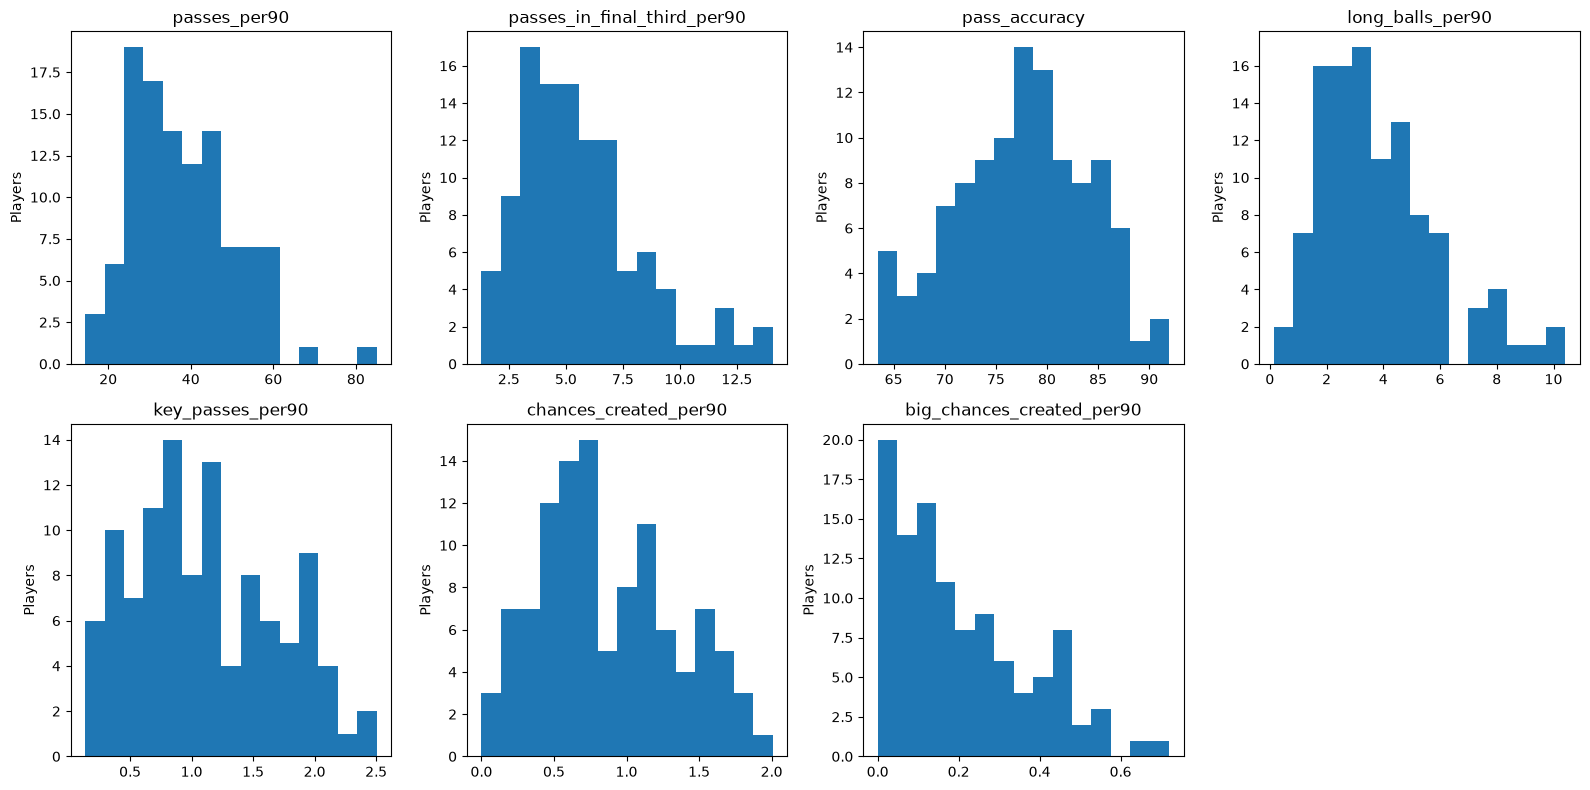

In [201]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, metric in zip(axes.flat, passing_metrics):
    ax.hist(midfielders[metric].dropna(), bins=15)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.set_ylabel('Players')

axes[-1, -1].axis('off')

plt.tight_layout()
plt.show()

Распределения показывают заметную разницу между полузащитниками по характеру работы с мячом.

По объёму передач большинство игроков находится примерно в диапазоне 20–50 передач за 90 минут, при этом есть несколько игроков с существенно более высокими значениями. Похожая картина наблюдается для передач в финальную треть: основная часть полузащитников находится в нижней части распределения, а отдельные игроки заметно выделяются.

Точность передач распределена более равномерно — большинство значений находится примерно между 70% и 85%. Для длинных передач распределение смещено в сторону небольших значений: у большинства игроков показатель находится ниже 6 передач за 90 минут.

Показатели создания моментов также имеют заметный разброс. При этом `big_chances_created_per90` в основном сосредоточен на низких значениях, а отдельные игроки заметно выделяются.

In [202]:
midfielders[
    ['player_name', 'team_name', 'passes_per90', 'minutes']
].sort_values('passes_per90', ascending=False).head(10)

,player_name,team_name,passes_per90,minutes
108,Elliot Watt,Motherwell,85.037905,2902
55,Callum McGregor,Celtic,69.899906,3197
270,Nicolas Raskin,Rangers,60.754039,2785
239,Marc Leonard,Hearts,60.346359,1126
1,Aaron Tshibola,Kilmarnock,59.729120,886
102,Dylan Levitt,Hibernian,58.695652,391
61,Cameron Devlin,Hearts,57.679766,2392
286,Reo Hatate,Celtic,57.314709,1754
276,Oscar Priestman,Motherwell,57.183227,1097
174,Joe Rothwell,Rangers,54.830097,412


In [203]:
midfielders[
    ['player_name', 'team_name', 'pass_accuracy', 'minutes']
].sort_values('pass_accuracy', ascending=False).head(10)

,player_name,team_name,pass_accuracy,minutes
55,Callum McGregor,Celtic,91.948642,3197
231,Lukas Fadinger,Motherwell,90.212024,2917
75,Connor Barron,Rangers,88.358432,1489
19,Allan Campbell,St. Mirren,88.042879,816
276,Oscar Priestman,Motherwell,87.647283,1097
1,Aaron Tshibola,Kilmarnock,86.642184,886
38,Beni Baningime,Hearts,86.415461,1742
174,Joe Rothwell,Rangers,86.356830,412
21,Andreas Skov Olsen,Rangers,86.308887,500
334,Tochi Phil Chukwuani,Rangers,85.621304,1024


In [204]:
midfielders[
    ['player_name', 'team_name', 'passes_in_final_third_per90', 'minutes']
].sort_values('passes_in_final_third_per90', ascending=False).head(10)

,player_name,team_name,passes_in_final_third_per90,minutes
108,Elliot Watt,Motherwell,14.079945,2902
153,Jack Thomson,Kilmarnock,13.829787,423
104,Dylan Tait,Falkirk,12.418349,2725
239,Marc Leonard,Hearts,12.229130,1126
25,Ante Palaversa,Aberdeen,12.053571,560
44,Blair Spittal,Hearts,11.735751,1158
217,Leighton Clarkson,Aberdeen,11.250000,448
85,Daniel Barlaser,Hibernian,10.128957,2559
270,Nicolas Raskin,Rangers,9.727110,2785
349,Yan Dhanda,Dundee,9.629458,2159


In [205]:
midfielders[
    ['player_name', 'team_name', 'key_passes_per90',
     'chances_created_per90', 'big_chances_created_per90', 'minutes']
].sort_values('chances_created_per90', ascending=False).head(10)

,player_name,team_name,key_passes_per90,chances_created_per90,big_chances_created_per90,minutes
217,Leighton Clarkson,Aberdeen,2.008929,2.008929,0.401786,448
15,Alexandros Kiziridis,Hearts,2.150499,1.861626,0.481455,2804
348,Will Ferry,Dundee United,2.463617,1.839917,0.467775,2886
29,Arne Engels,Celtic,1.971130,1.791936,0.268790,2009
326,Stuart Armstrong,Aberdeen,1.903846,1.730769,0.346154,2080
140,Greg Kiltie,Kilmarnock,2.148438,1.679688,0.546875,2304
234,Luke McCowan,Celtic,2.106538,1.670702,0.435835,1239
93,Declan John,St. Mirren,1.741691,1.665966,0.567943,2377
75,Connor Barron,Rangers,1.752854,1.631968,0.362660,1489
40,Benjamin Nygren,Celtic,2.124312,1.593234,0.283242,2542


Если смотреть на показатели в совокупности, особенно выделяются игроки, которые появляются сразу в нескольких рейтингах.

Elliot Watt лидирует сразу по двум показателям: передачам в финальную треть (14.08 за 90 минут) и общему количеству передач (85.04 за 90 минут). При этом он сыграл почти 2900 минут, поэтому показатели получены на достаточно большой выборке.

Callum McGregor сочетает второе место по количеству передач (69.90 за 90 минут) с лучшей точностью передач (91.95%), что выделяет его как одного из наиболее надёжных игроков при большом объёме пасовой работы.

Marc Leonard и Nicolas Raskin также входят в топ по общему количеству передач — 60.35 и 60.75 за 90 минут соответственно. При этом Leonard заметно чаще продвигает мяч в финальную треть (12.23 против 9.73).

Отдельно выделяется Leighton Clarkson: он входит в лидеры как по созданным моментам (2.01 за 90 минут), так и по передачам в финальную треть (11.25). Однако его результат получен всего за 448 минут, поэтому здесь стоит учитывать размер выборки.

Среди игроков, ориентированных на создание моментов, выделяются Alexandros Kiziridis, Will Ferry, Greg Kiltie и Declan John. Kiziridis и Ferry входят в топ по созданным моментам, а Kiltie и John показывают особенно высокие значения созданных больших моментов — 0.55 и 0.57 за 90 минут соответственно.

В целом можно выделить несколько разных профилей: Watt и McGregor — большой объём пасовой работы, Leonard и Raskin — объём передач в сочетании с продвижением мяча, а Clarkson, Kiziridis, Ferry, Kiltie и John — более выраженная ориентация на создание моментов.

Посмотрим на взаимосвязи между этими метриками

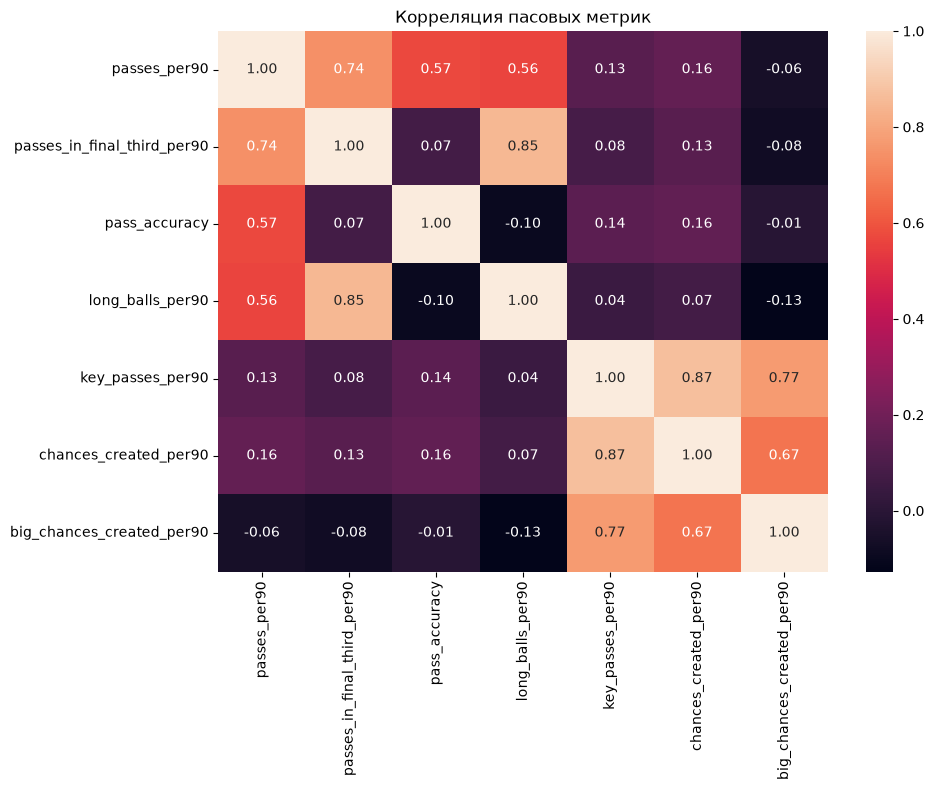

In [206]:
corr = midfielders[passing_metrics].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f'
)

plt.title('Корреляция пасовых метрик')
plt.tight_layout()
plt.show()

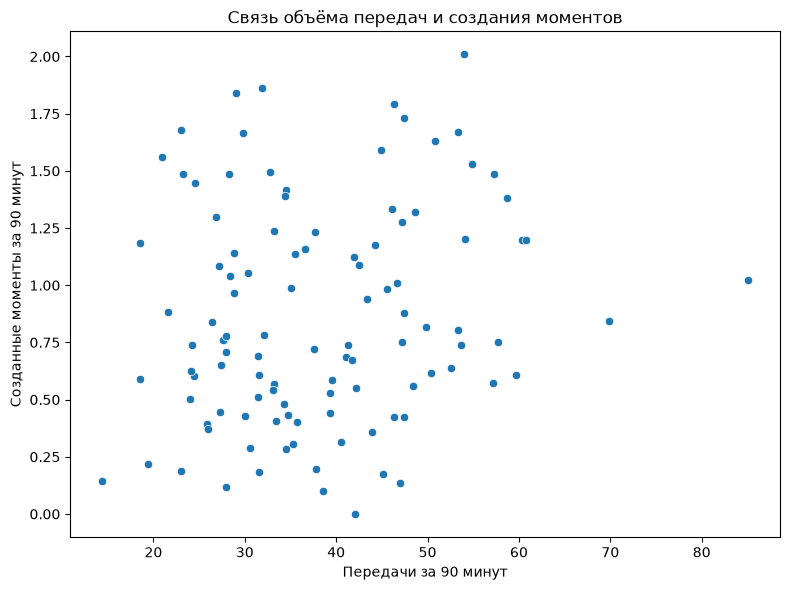

In [207]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=midfielders,
    x='passes_per90',
    y='chances_created_per90'
)

plt.xlabel('Передачи за 90 минут')
plt.ylabel('Созданные моменты за 90 минут')
plt.title('Связь объёма передач и создания моментов')

plt.tight_layout()
plt.show()

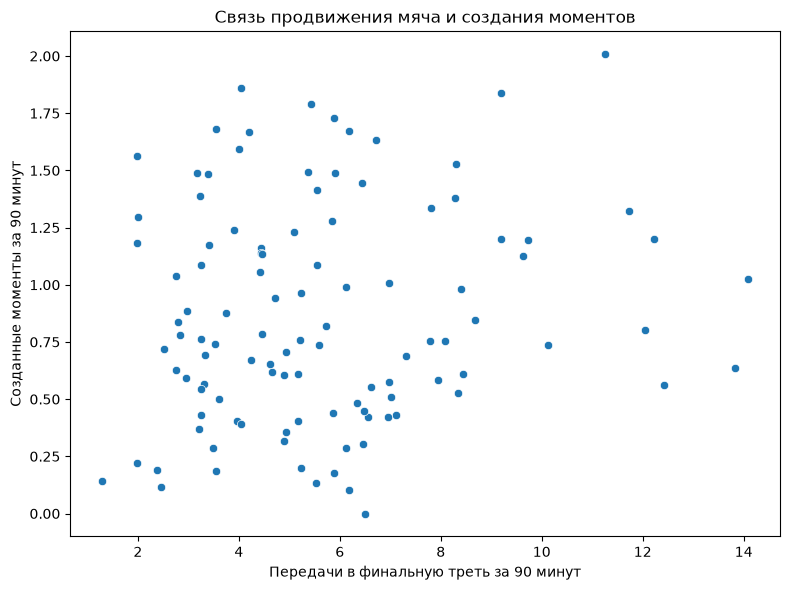

In [208]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=midfielders,
    x='passes_in_final_third_per90',
    y='chances_created_per90'
)

plt.xlabel('Передачи в финальную треть за 90 минут')
plt.ylabel('Созданные моменты за 90 минут')
plt.title('Связь продвижения мяча и создания моментов')

plt.tight_layout()
plt.show()

Корреляционный анализ показывает, что количество передач и продвижение мяча связаны между собой: количество передач за 90 минут имеет сильную положительную связь с передачами в финальную треть (**r = 0.74**). При этом передачи в финальную треть особенно сильно связаны с длинными передачами (**r = 0.85**).

Метрики, связанные с созданием моментов, образуют отдельную группу. `key_passes_per90` имеет очень сильную связь с `chances_created_per90` (**r = 0.87**), а также заметно связан с `big_chances_created_per90` (**r = 0.77**). Это логично: игроки, которые чаще отдают ключевые передачи, как правило, чаще создают моменты и большие моменты.

При этом между количеством передач и созданием моментов связь оказывается слабой: корреляция `passes_per90` с `chances_created_per90` составляет всего **0.16**, а с `big_chances_created_per90` — **-0.07**. Аналогично, передачи в финальную треть практически не связаны с созданием моментов (**r = 0.13**).

На графиках это также хорошо видно: точки сильно разбросаны, поэтому увеличение общего количества передач или передач в финальную треть само по себе не означает пропорционального роста количества созданных моментов.

Таким образом, в передачах можно выделить два относительно разных направления: **объём и продвижение мяча** и **создание моментов**. Эти характеристики могут сочетаться у одного игрока, но высокая активность в передачах сама по себе ещё не говорит о его эффективности при создании моментов.

#### Дриблинг

In [209]:
dribbling_metrics = [
    'dribble_attempts_per90',
    'successful_dribbles_per90',
    'dribble_success',
    'dispossessed_per90'
]

midfielders[dribbling_metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
dribble_attempts_per90,108.0,1.680151,1.153565,0.123457,0.922878,1.286488,2.250041,5.476974
successful_dribbles_per90,108.0,0.826087,0.600050,0.000000,0.412799,0.641683,1.132707,2.812500
dribble_success,108.0,48.841286,17.585589,0.000000,38.956093,49.140212,59.714912,100.000000
dispossessed_per90,108.0,0.952719,0.515645,0.117493,0.570274,0.889452,1.221611,2.715173


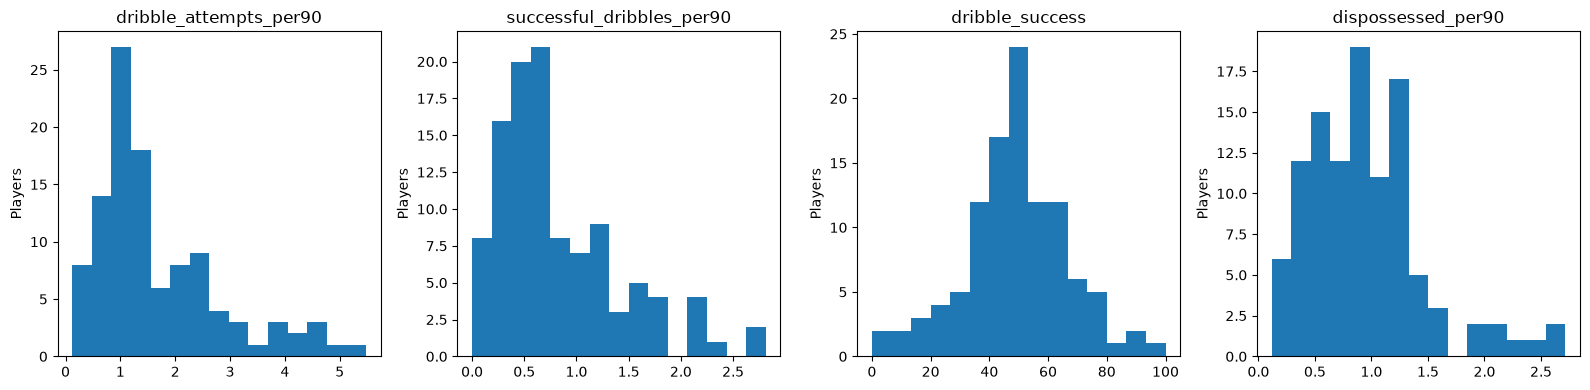

In [210]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, metric in zip(axes.flat, dribbling_metrics):
    ax.hist(midfielders[metric].dropna(), bins=15)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.set_ylabel('Players')

plt.tight_layout()
plt.show()

В среднем полузащитники выполняют **1.70 попытки обводки за 90 минут**, из которых **0.84 заканчиваются успешно**. Средняя успешность обводок составляет около **49%**. При этом в среднем игроки теряют мяч после попытки обводки **0.97 раза за 90 минут**.

Разброс показателей достаточно большой: количество попыток обводки варьируется от **0.12 до 5.48 за 90 минут**, а успешность — от **0% до 100%**. Это указывает на заметные различия в стиле игры полузащитников: одни редко идут в обводку, другие делают это значительно чаще.

In [211]:
midfielders[
    ['player_name', 'team_name', 'dribble_attempts_per90', 'minutes']
].sort_values('dribble_attempts_per90', ascending=False).head(10)

,player_name,team_name,dribble_attempts_per90,minutes
211,Kristijan Trapanovski,Dundee United,5.476974,608
257,Mikey Moore,Rangers,4.826630,2163
60,Cameron Congreve,Dundee,4.652778,2592
145,Ibrahim Sa’id,Motherwell,4.511979,2254
159,James Forrest,Celtic,4.464752,766
201,Kenan Bilalovic,Aberdeen,4.326923,624
215,Kyrell Wilson,Falkirk,4.108146,1424
97,Djeidi Gassama,Rangers,4.004944,2427
15,Alexandros Kiziridis,Hearts,3.915835,2804
293,Roland Idowu,St. Mirren,3.770365,1289


In [212]:
midfielders[
    ['player_name', 'team_name', 'successful_dribbles_per90', 'minutes']
].sort_values('successful_dribbles_per90', ascending=False).head(10)

,player_name,team_name,successful_dribbles_per90,minutes
211,Kristijan Trapanovski,Dundee United,2.812500,608
145,Ibrahim Sa’id,Motherwell,2.635315,2254
201,Kenan Bilalovic,Aberdeen,2.307692,624
293,Roland Idowu,St. Mirren,2.234290,1289
97,Djeidi Gassama,Rangers,2.187886,2427
257,Mikey Moore,Rangers,2.122053,2163
159,James Forrest,Celtic,2.114883,766
60,Cameron Congreve,Dundee,1.805556,2592
330,Thelo Aasgaard,Rangers,1.785124,1815
215,Kyrell Wilson,Falkirk,1.769663,1424


In [213]:
dribble_attempts_q1 = midfielders['dribble_attempts_per90'].quantile(0.25)

midfielders[
    midfielders['dribble_attempts_per90'] > dribble_attempts_q1
][
    ['player_name', 'team_name', 'dribble_success', 'dribble_attempts_per90', 'minutes']
].sort_values('dribble_success', ascending=False).head(10)

,player_name,team_name,dribble_success,dribble_attempts_per90,minutes
174,Joe Rothwell,Rangers,87.500000,1.092233,412
307,Samson Adeniran Lawal,Livingston,80.416667,2.217899,771
330,Thelo Aasgaard,Rangers,75.173160,2.479339,1815
21,Andreas Skov Olsen,Rangers,75.000000,1.620000,500
19,Allan Campbell,St. Mirren,70.833333,1.102941,816
48,Bradley Lyons,Kilmarnock,69.791667,1.014706,2040
279,Panutche Amadu Pereira Camará,Dundee United,68.921569,2.383420,1737
108,Elliot Watt,Motherwell,68.333333,1.023432,2902
112,Emmanuel Agyei,Dundee United,67.857143,2.227222,889
197,Keanu Baccus,St. Mirren,66.666667,1.004785,1254


In [214]:
midfielders[
    ['player_name', 'team_name', 'dispossessed_per90', 'minutes']
].sort_values('dispossessed_per90', ascending=False).head(10)

,player_name,team_name,dispossessed_per90,minutes
145,Ibrahim Sa’id,Motherwell,2.715173,2254
234,Luke McCowan,Celtic,2.542373,1239
338,Tony Yogane,Dundee,2.449554,2131
57,Callum Slattery,Motherwell,2.361290,2325
257,Mikey Moore,Rangers,2.038835,2163
293,Roland Idowu,St. Mirren,2.024825,1289
221,Lewis Smith,Livingston,1.996143,2074
58,Calvin Miller,Falkirk,1.891147,2903
4,Adil Aouchiche,Aberdeen,1.615925,1281
60,Cameron Congreve,Dundee,1.562500,2592


По количеству попыток обводки заметно выделяется **Kristijan Trapanovski** — **5.48 за 90 минут**. Далее идут **Mikey Moore** (4.83), **Cameron Congreve** (4.65) и **Ibrahim Sa'id** (4.51). При этом Trapanovski, Sa'id, Mikey Moore и другие игроки из этой группы также входят в топ по успешным обводкам.

По количеству успешных обводок лидируют **Kristijan Trapanovski** (**2.81 за 90 минут**), **Ibrahim Sa'id** (2.64), **Kenan Bilalovic** (2.31) и **Roland Idowu** (2.23). Несколько игроков — Trapanovski, Sa'id, Bilalovic, Idowu и Djeidi Gassama — одновременно входят в топ по попыткам и успешным обводкам, что говорит об их высокой активности в обводках.

Если учитывать только игроков, у которых количество попыток обводки выше 25-го процентиля, лидером по успешности становится **Joe Rothwell** — **87.5%**, однако у него всего **1.09 попытки за 90 минут** и 412 сыгранных минут. Среди игроков с более высокой активностью выделяются **Samson Adeniran Lawal** (80.4% при 2.22 попытках), **Thelo Aasgaard** (75.2% при 2.48) и **Panutche Amadu Pereira Camará** (68.9% при 2.38). **Elliot Watt** также показывает высокую эффективность — **68.3%**, при этом сыграл 2902 минуты.

По потерям мяча после попыток обводки лидирует **Ibrahim Sa'id** — **2.72 за 90 минут**. Он одновременно входит в число лидеров по попыткам и успешным обводкам, поэтому его высокий показатель потерь связан не с низкой эффективностью, а с очень активным использованием обводок.

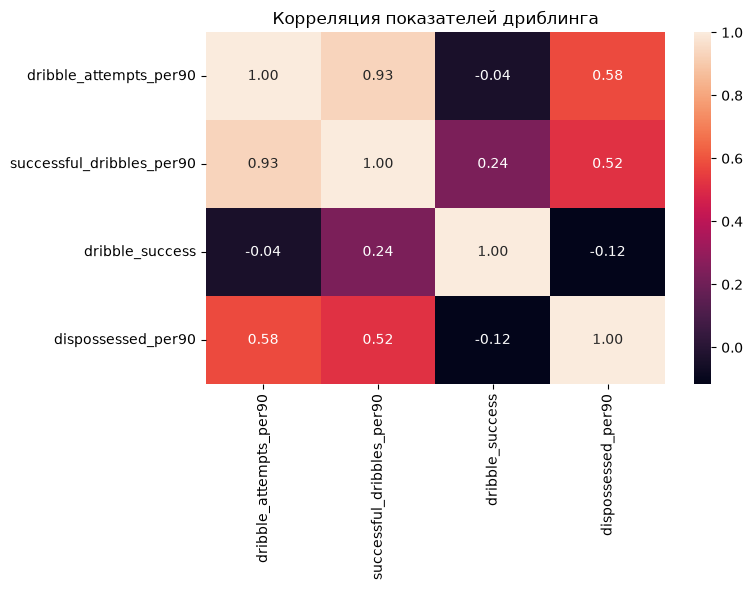

In [215]:
corr = midfielders[dribbling_metrics].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f'
)

plt.title('Корреляция показателей дриблинга')
plt.tight_layout()
plt.show()

Корреляционный анализ показывает очень сильную связь между количеством попыток обводки и успешными обводками за 90 минут (r = 0.93). То есть игроки, которые чаще идут в обводку, в среднем и чаще выполняют успешные обводки.

Количество попыток обводки также имеет умеренную положительную связь с потерями мяча (r = 0.57), а успешные обводки — чуть более слабую (r = 0.51). Это означает, что высокая активность в дриблинге обычно сопровождается большим количеством потерь мяча.

При этом эффективность обводок (dribble_success) почти не связана с количеством попыток (r = -0.04) и слабо связана с успешными обводками (r = 0.23). Между эффективностью обводок и потерями мяча наблюдается слабая отрицательная связь (r = -0.13).

Таким образом, в данных можно выделить два разных аспекта дриблинга: активность — количество попыток и успешных обводок, и эффективность — доля успешных попыток. При этом более активный дриблинг связан с большим количеством потерь мяча, а сама эффективность обводок практически не зависит от их количества.

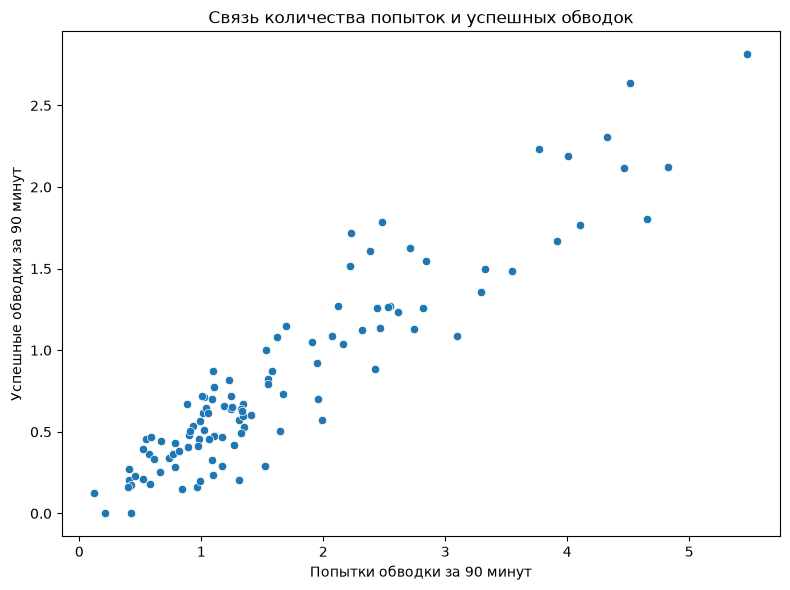

In [216]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=midfielders,
    x='dribble_attempts_per90',
    y='successful_dribbles_per90'
)

plt.xlabel('Попытки обводки за 90 минут')
plt.ylabel('Успешные обводки за 90 минут')
plt.title('Связь количества попыток и успешных обводок')

plt.tight_layout()
plt.show()

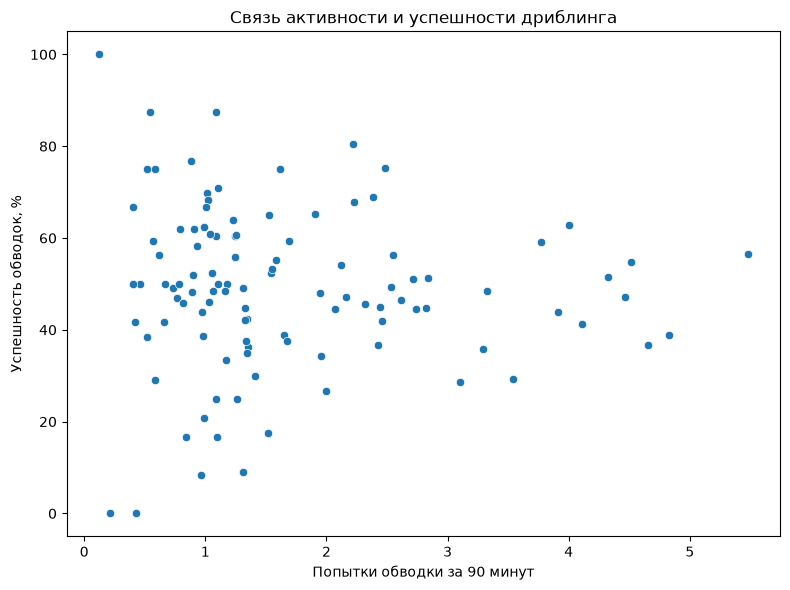

In [217]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=midfielders,
    x='dribble_attempts_per90',
    y='dribble_success'
)

plt.xlabel('Попытки обводки за 90 минут')
plt.ylabel('Успешность обводок, %')
plt.title('Связь активности и успешности дриблинга')

plt.tight_layout()
plt.show()

По первому графику видно практически линейную положительную зависимость между попытками обводки и успешными обводками. С увеличением количества попыток растёт и число успешных обводок, что соответствует высокой корреляции **r = 0.93**. При этом разброс становится больше у игроков с высокой активностью: при одинаковом количестве попыток игроки могут заметно отличаться по числу успешных обводок.

Второй график показывает уже другую картину. Между количеством попыток обводки и их успешностью нет выраженной зависимости: игроки с похожей активностью имеют очень разный процент успешных обводок. Это соответствует корреляции всего **r = -0.04**. То есть само по себе большое количество попыток не означает ни более высокую, ни более низкую эффективность дриблинга.

В целом графики хорошо показывают различие между **активностью и эффективностью**: количество попыток напрямую связано с количеством успешных обводок, но почти не связано с процентом успешности.


#### Атакующие метрики

In [218]:
attacking_metrics = [
    'goals_per90',
    'assists_per90',
    'shots_total_per90',
    'shots_on_target_per90',
]

midfielders[attacking_metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
goals_per90,108.0,0.113686,0.117837,0.000000,0.000000,0.093749,0.165032,0.566483
assists_per90,108.0,0.094598,0.103012,0.000000,0.000000,0.073602,0.158600,0.540000
shots_total_per90,108.0,1.275641,0.750719,0.123457,0.654928,1.197209,1.645606,3.614173
shots_on_target_per90,108.0,0.402329,0.294429,0.000000,0.190780,0.358619,0.565082,1.345397


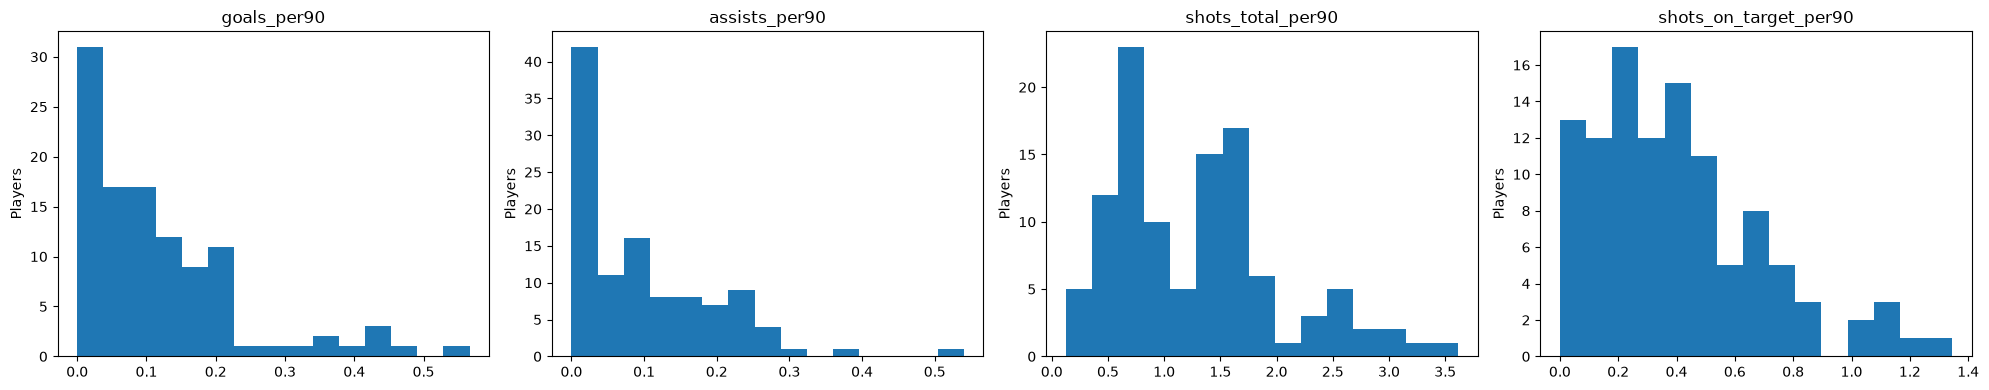

In [219]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, metric in zip(axes.flat, attacking_metrics):
    ax.hist(midfielders[metric].dropna(), bins=15)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.set_ylabel('Players')

plt.tight_layout()
plt.show()

По распределениям видно, что показатели результативности полузащитников в основном имеют небольшие значения и большое количество нулей. Среднее значение goals_per90 составляет 0.12, а медиана — 0, тогда как для assists_per90 среднее равно 0.09, а медиана также 0. Это ожидаемо: для полузащитников голы и ассисты происходят значительно реже, чем удары.

Для shots_total_per90 среднее составляет 1.28, а медиана — 1.24. У shots_on_target_per90 среднее значение равно 0.40, медиана — 0.36. В отличие от голов и ассистов, эти показатели распределены более равномерно.

Таким образом, в атакующей активности можно условно выделить две группы: результативные действия, которые встречаются относительно редко, и частоту ударов по воротам, которая характерна для значительно большего числа игроков.

In [220]:
midfielders[
    ['player_name', 'team_name', 'goals_per90', 'minutes']
].sort_values('goals_per90', ascending=False).head(10)

,player_name,team_name,goals_per90,minutes
40,Benjamin Nygren,Celtic,0.566483,2542
41,Benjamin Tomaso Broggio,Falkirk,0.476695,944
201,Kenan Bilalovic,Aberdeen,0.432692,624
127,Findlay Curtis,Kilmarnock,0.425197,1270
12,Alex Oxlade-Chamberlain,Celtic,0.423529,425
186,Josh Campbell,Hibernian,0.379747,711
144,Hyun-Jun Yang,Celtic,0.348162,2068
330,Thelo Aasgaard,Rangers,0.347107,1815
221,Lewis Smith,Livingston,0.303761,2074
257,Mikey Moore,Rangers,0.291262,2163


In [221]:
midfielders[
    ['player_name', 'team_name', 'assists_per90', 'minutes']
].sort_values('assists_per90', ascending=False).head(10)

,player_name,team_name,assists_per90,minutes
21,Andreas Skov Olsen,Rangers,0.540000,500
186,Josh Campbell,Hibernian,0.379747,711
57,Callum Slattery,Motherwell,0.309677,2325
58,Calvin Miller,Falkirk,0.279022,2903
140,Greg Kiltie,Kilmarnock,0.273438,2304
266,Nicky Cadden,Hibernian,0.272232,1653
15,Alexandros Kiziridis,Hearts,0.256776,2804
184,Jordan Obita,Hibernian,0.247253,1820
60,Cameron Congreve,Dundee,0.243056,2592
125,Felix Passlack,Hibernian,0.243024,1111


In [222]:
midfielders[
    ['player_name', 'team_name', 'shots_total_per90', 'minutes']
].sort_values('shots_total_per90', ascending=False).head(10)

,player_name,team_name,shots_total_per90,minutes
127,Findlay Curtis,Kilmarnock,3.614173,1270
40,Benjamin Nygren,Celtic,3.257278,2542
211,Kristijan Trapanovski,Dundee United,3.108553,608
159,James Forrest,Celtic,2.937337,766
234,Luke McCowan,Celtic,2.832930,1239
57,Callum Slattery,Motherwell,2.787097,2325
4,Adil Aouchiche,Aberdeen,2.599532,1281
257,Mikey Moore,Rangers,2.579750,2163
330,Thelo Aasgaard,Rangers,2.578512,1815
107,Elijah Henry Just,Motherwell,2.530522,2703


In [223]:
midfielders[
    ['player_name', 'team_name', 'shots_on_target_per90', 'minutes']
].sort_values('shots_on_target_per90', ascending=False).head(10)

,player_name,team_name,shots_on_target_per90,minutes
40,Benjamin Nygren,Celtic,1.345397,2542
211,Kristijan Trapanovski,Dundee United,1.184211,608
127,Findlay Curtis,Kilmarnock,1.133858,1270
257,Mikey Moore,Rangers,1.123440,2163
330,Thelo Aasgaard,Rangers,1.090909,1815
12,Alex Oxlade-Chamberlain,Celtic,1.058824,425
57,Callum Slattery,Motherwell,1.006452,2325
186,Josh Campbell,Hibernian,0.886076,711
107,Elijah Henry Just,Motherwell,0.865705,2703
4,Adil Aouchiche,Aberdeen,0.843091,1281


По голам за 90 минут лидирует Benjamin Nygren — 0.57, далее идут Benjamin Tomaso Broggio (0.48) и Kenan Bilalovic (0.43). При этом у некоторых лидеров относительно небольшое игровое время, поэтому показатели необходимо рассматривать вместе с количеством минут.

По ассистам выделяется Andreas Skov Olsen — 0.54 ассиста за 90 минут, а также Josh Campbell (0.38) и Callum Slattery (0.31). При этом Campbell и Slattery также входят в число лидеров по другим атакующим показателям.

По количеству ударов лидируют Findlay Curtis — 3.61 за 90 минут, Benjamin Nygren (3.26) и Kristijan Trapanovski (3.11). По ударам в створ в лидерах снова находятся Benjamin Nygren (1.35), Kristijan Trapanovski (1.18) и Findlay Curtis (1.13).

Особенно выделяются Benjamin Nygren, Findlay Curtis, Kristijan Trapanovski, Thelo Aasgaard и Callum Slattery, которые появляются сразу в нескольких рейтингах, что указывает на высокую атакующую активность по нескольким показателям.

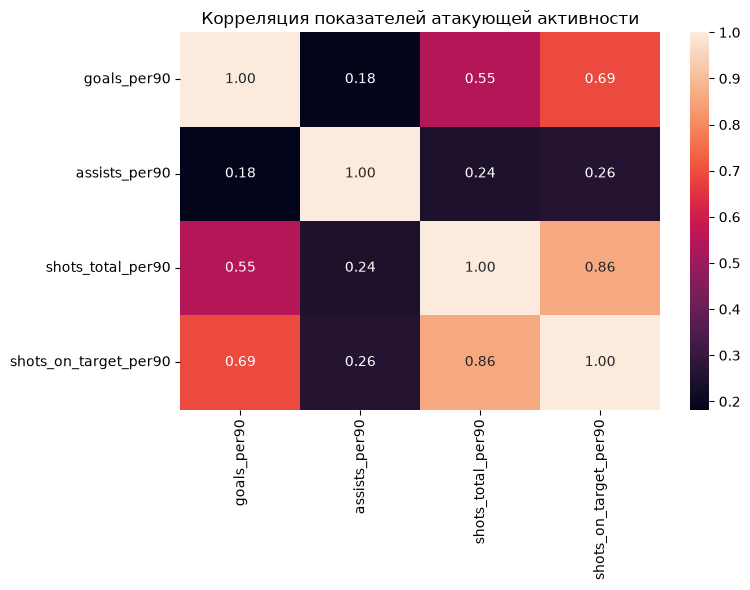

In [224]:
corr = midfielders[attacking_metrics].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f'
)

plt.title('Корреляция показателей атакующей активности')
plt.tight_layout()
plt.show()

Наиболее сильная связь наблюдается между количеством ударов и ударами в створ (r = 0.86). Это логично: игроки, которые чаще бьют по воротам, в среднем чаще наносят и удары в створ.

Количество ударов также имеет заметную положительную связь с голами за 90 минут (r = 0.55), а ещё сильнее с голами связаны удары в створ (r = 0.70). Это показывает, что для результативности важна не только частота ударов, но и их точность.

Между ассистами и остальными показателями связи значительно слабее: с ударами r = 0.26, с ударами в створ r = 0.29, а с голами r = 0.18. Таким образом, ассисты в этой выборке представляют относительно самостоятельный показатель и не определяются напрямую тем, как часто игрок бьет по воротам.

#### Оборонительные характеристики

In [225]:
defensive_metrics = [
    'tackles_per90',
    'interceptions_per90'
]

midfielders[defensive_metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
tackles_per90,108.0,1.889836,0.749760,0.675739,1.291773,1.778837,2.348745,4.680851
interceptions_per90,108.0,0.925168,0.486253,0.138889,0.579932,0.861998,1.182914,2.500000


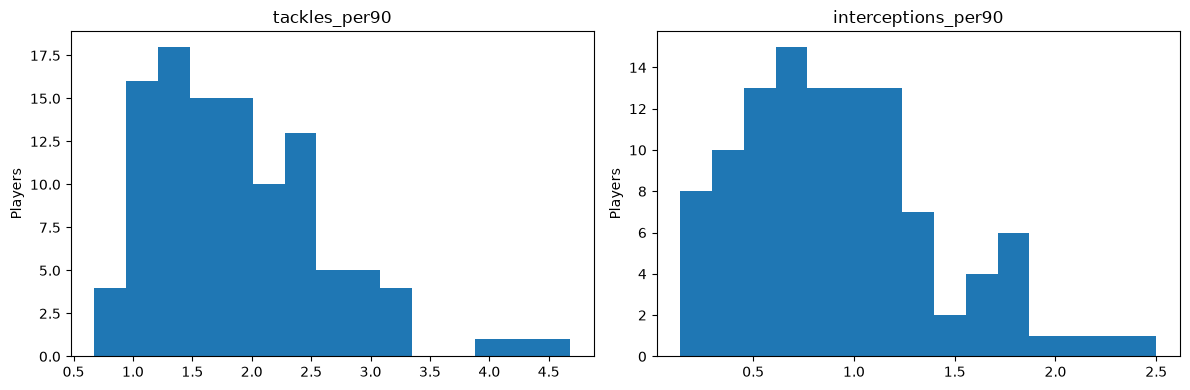

In [226]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes.flat, defensive_metrics):
    ax.hist(midfielders[metric].dropna(), bins=15)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.set_ylabel('Players')

plt.tight_layout()

plt.show()

По распределениям видно, что полузащитники в среднем выполняют 1.91 отбора за 90 минут и 0.92 перехвата за 90 минут. При этом разброс отборов заметно выше: стандартное отклонение составляет 0.75, а максимальное значение достигает 4.68. Для перехватов стандартное отклонение ниже — 0.48, максимальное значение составляет 2.50.

Медиана составляет 1.86 отбора и 0.87 перехвата за 90 минут. Это показывает, что большинство игроков находится относительно близко к этим значениям, но отдельные полузащитники заметно выделяются высокой оборонительной активностью.

In [227]:
midfielders[
    ['player_name', 'team_name', 'tackles_per90', 'minutes']
].sort_values('tackles_per90', ascending=False).head(10)

,player_name,team_name,tackles_per90,minutes
153,Jack Thomson,Kilmarnock,4.680851,423
61,Cameron Devlin,Hearts,4.251672,2392
137,Graeme Shinnie,Aberdeen,3.969849,1791
260,Mohamad Sylla,Livingston,3.237705,2196
215,Kyrell Wilson,Falkirk,3.223315,1424
19,Allan Campbell,St. Mirren,3.198529,816
239,Marc Leonard,Hearts,3.117229,1126
222,Liam Donnelly,St. Mirren,3.059789,853
75,Connor Barron,Rangers,3.022163,1489
307,Samson Adeniran Lawal,Livingston,2.918288,771


In [228]:
midfielders[
    ['player_name', 'team_name', 'interceptions_per90', 'minutes']
].sort_values('interceptions_per90', ascending=False).head(10)

,player_name,team_name,interceptions_per90,minutes
260,Mohamad Sylla,Livingston,2.500000,2196
61,Cameron Devlin,Hearts,2.257525,2392
113,Emmanuel Danso,Livingston,2.052632,570
112,Emmanuel Agyei,Dundee United,2.024747,889
196,Kanayochukwu Megwa,Hibernian,1.828737,689
25,Ante Palaversa,Aberdeen,1.767857,560
148,Islam Chesnokov,Hearts,1.764706,408
47,Brad Spencer,Falkirk,1.759777,3222
239,Marc Leonard,Hearts,1.758437,1126
174,Joe Rothwell,Rangers,1.747573,412


По отборам за 90 минут лидирует Jack Thomson — 4.68, однако он сыграл только 423 минуты. Далее идут Cameron Devlin (4.25) и Graeme Shinnie (3.97), которые имеют значительно больше игрового времени.

По перехватам лидирует Mohamad Sylla — 2.50 за 90 минут, далее идут Cameron Devlin (2.26) и Emmanuel Danso (2.05).

Mohamad Sylla, Cameron Devlin и Marc Leonard входят в топ сразу по обоим показателям, что выделяет их среди полузащитников с высокой активностью как в отборах, так и в перехватах.

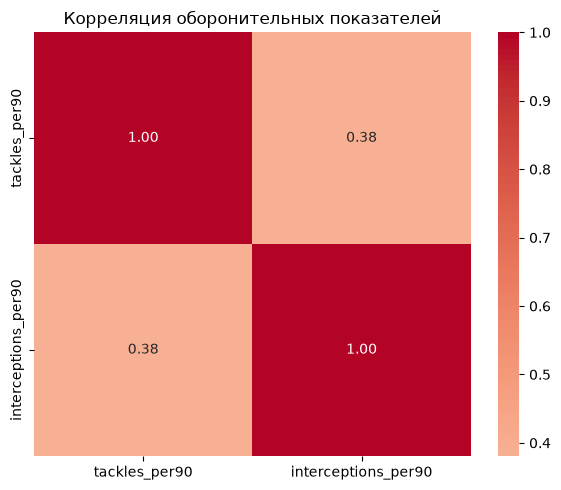

In [229]:
corr = midfielders[defensive_metrics].corr()

plt.figure(figsize=(6, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Корреляция оборонительных показателей')
plt.tight_layout()
plt.show()

Между отборами и перехватами наблюдается умеренная положительная связь (r = 0.39). То есть игроки, которые чаще выполняют отборы, в среднем также чаще совершают перехваты.

При этом связь не является сильной, что говорит о том, что эти показатели характеризуют разные стороны оборонительной игры. Высокое количество отборов не обязательно означает такое же высокое количество перехватов.

#### Комплексная оценка профиля полузащитников

Для комплексного сравнения полузащитников показатели из предыдущих разделов объединены в четыре игровых профиля: **передачи, дриблинг, атакующая и оборонительная активность**.

Для сопоставления показателей с разными единицами измерения каждую выбранную метрику нормируем в диапазон **[0, 1]** методом Min-Max нормализации. После этого внутри профиля рассчитывается среднее значение нормированных показателей.

В профиль **передач** включены `passes_per90` и `key_passes_per90`, которые характеризуют общий объём передач и участие в создании моментов. Для **дриблинга** используется `dribble_attempts_per90`, отражающий склонность игрока использовать обводки. В **атакующую активность** включён `shots_total_per90`, характеризующий частоту ударов. **Оборонительная активность** оценивается по `tackles_per90` и `interceptions_per90`.

Если профиль включает две метрики, каждой из них присваивается одинаковый вес **0.5**. Для профилей с одной метрикой её нормированное значение используется напрямую.

Таким образом, для каждого полузащитника формируются четыре итоговых показателя, позволяющие сравнивать игроков по характеру их игровой активности.

In [230]:
profile_metrics = {
    'passing': [
        'passes_per90',
        'key_passes_per90'
    ],
    'dribbling': [
        'dribble_attempts_per90'
    ],
    'attacking': [
        'shots_total_per90'
    ],
    'defending': [
        'tackles_per90',
        'interceptions_per90'
    ]
}

In [231]:
normalized_metrics = midfielders.copy()

for metrics in profile_metrics.values():
    for metric in metrics:
        normalized_metrics[metric] = (
            (normalized_metrics[metric] - normalized_metrics[metric].min())
            / (normalized_metrics[metric].max() - normalized_metrics[metric].min())
        )

In [232]:
normalized_metrics['passing_score'] = (
    normalized_metrics['passes_per90']
    + normalized_metrics['key_passes_per90']
) / 2

normalized_metrics['dribbling_score'] = (
    normalized_metrics['dribble_attempts_per90']
)

normalized_metrics['attacking_score'] = (
    normalized_metrics['shots_total_per90']
)

normalized_metrics['defending_score'] = (
    normalized_metrics['tackles_per90']
    + normalized_metrics['interceptions_per90']
) / 2

In [233]:
profile_scores = [
    'passing_score',
    'dribbling_score',
    'attacking_score',
    'defending_score'
]

normalized_metrics[
    ['player_name', 'team_name'] + profile_scores
].head(10)

,player_name,team_name,passing_score,dribbling_score,attacking_score,defending_score
1,Aaron Tshibola,Kilmarnock,0.506665,0.052837,0.372034,0.470224
4,Adil Aouchiche,Aberdeen,0.477415,0.410019,0.709331,0.355767
5,Afeez Aremu,Aberdeen,0.196823,0.161390,0.085868,0.561695
12,Alex Oxlade-Chamberlain,Celtic,0.599932,0.372501,0.510619,0.187412
13,Alexander Jensen,Aberdeen,0.383182,0.265701,0.116865,0.311609
15,Alexandros Kiziridis,Hearts,0.549076,0.708390,0.617475,0.138016
19,Allan Campbell,St. Mirren,0.307365,0.182961,0.122615,0.495742
21,Andreas Skov Olsen,Rangers,0.629531,0.279544,0.377156,0.097292
25,Ante Palaversa,Aberdeen,0.416766,0.157061,0.148795,0.461235
29,Arne Engels,Celtic,0.613628,0.085724,0.362474,0.226468


Для оценки распределения полученных профилей используется boxplot. Он позволяет сравнить медианы, разброс значений и выделить игроков, которые заметно отличаются от основной группы полузащитников.

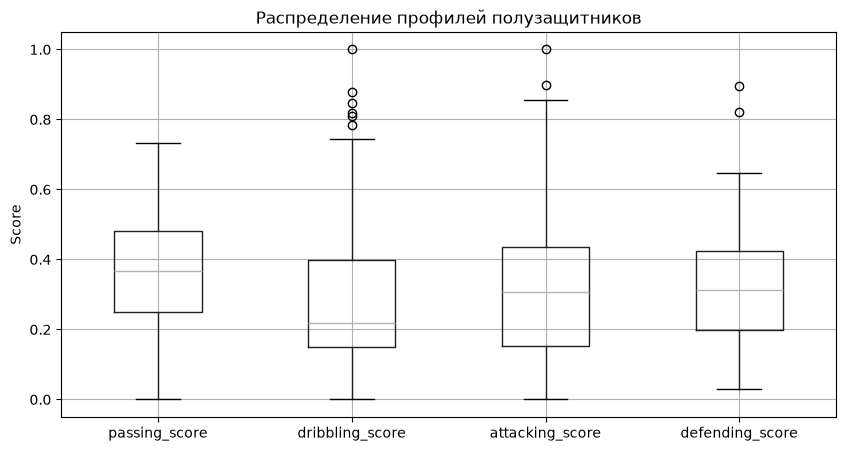

In [234]:
plt.figure(figsize=(10, 5))

normalized_metrics[profile_scores].boxplot()

plt.ylabel('Score')
plt.title('Распределение профилей полузащитников')

plt.show()

Для оценки взаимосвязи между игровыми профилями рассчитана корреляционная матрица. Она позволяет определить, насколько выраженность одного направления игры связана с другими направлениями.

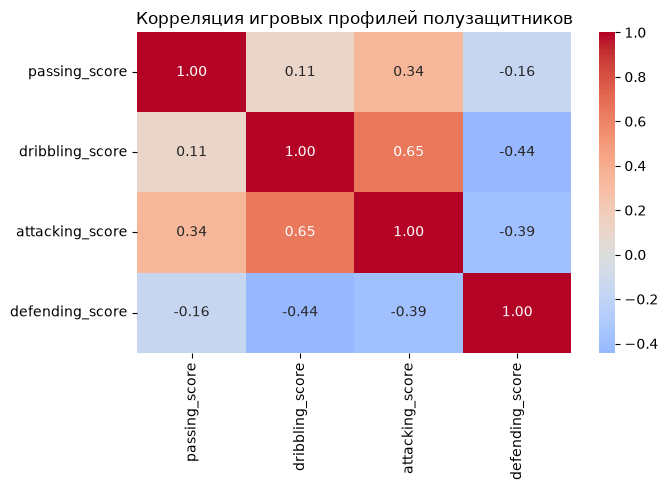

In [235]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    normalized_metrics[profile_scores].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Корреляция игровых профилей полузащитников')

plt.tight_layout()

plt.show()

Наиболее сильная положительная связь наблюдается между **дриблингом и атакующей активностью** (**r = 0.65**). Это означает, что полузащитники, которые чаще используют обводки, в этой выборке также чаще наносят удары.

Между **передачами и атакующей активностью** связь умеренная (**r = 0.34**), тогда как между передачами и дриблингом она практически отсутствует (**r = 0.09**). Таким образом, высокий показатель передач сам по себе не связан с высокой склонностью к обводкам.

Оборонительный профиль имеет отрицательную связь с атакующими показателями: с дриблингом **r = -0.45**, с атакующей активностью **r = -0.40**. Связь с передачами слабая (**r = -0.16**).

В целом результаты показывают, что выбранные профили отражают разные стороны игровой активности полузащитников. При этом **атакующая активность и дриблинг** имеют наиболее выраженную взаимосвязь, а **передачи и дриблинг** практически независимы.

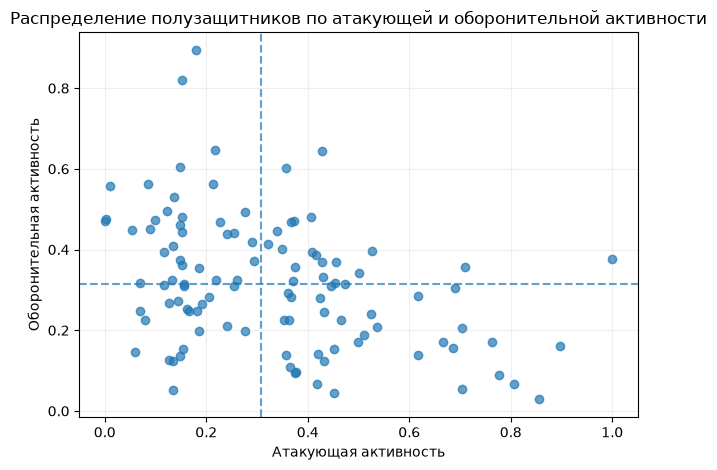

In [236]:
plt.scatter(
    normalized_metrics['attacking_score'],
    normalized_metrics['defending_score'],
    alpha=0.7
)

attacking_median = normalized_metrics['attacking_score'].median()
defending_median = normalized_metrics['defending_score'].median()

plt.axvline(
    attacking_median,
    linestyle='--',
    alpha=0.7
)

plt.axhline(
    defending_median,
    linestyle='--',
    alpha=0.7
)

plt.xlabel('Атакующая активность')
plt.ylabel('Оборонительная активность')
plt.title('Распределение полузащитников по атакующей и оборонительной активности')

plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

Для общей оценки выборки построен scatter plot, где по оси X отложена **атакующая активность**, а по оси Y — **оборонительная активность**. Каждая точка соответствует одному полузащитнику.

Пунктирные линии показывают медианные значения соответствующих показателей и условно разделяют игроков на четыре группы: с относительно высокой или низкой атакующей и оборонительной активностью.

На графике заметна отрицательная взаимосвязь между двумя показателями: игроки с высокой атакующей активностью чаще имеют относительно невысокий показатель оборонительной активности. Это соответствует рассчитанному ранее коэффициенту корреляции **r = -0.40**.

Таким образом, scatter plot позволяет увидеть общее распределение полузащитников и различия в характере их игровой активности. Для более детального анализа отдельных игроков далее можно использовать **radar chart**, который одновременно показывает все четыре выбранных игровых профиля.

In [237]:
normalized_metrics[
    ['player_name'] + profile_scores
].sort_values(
    'attacking_score',
    ascending=False
).head(10)

,player_name,passing_score,dribbling_score,attacking_score,defending_score
127,Findlay Curtis,0.366168,0.638804,1.000000,0.375956
40,Benjamin Nygren,0.635523,0.340679,0.897759,0.160890
211,Kristijan Trapanovski,0.281529,1.000000,0.855153,0.028453
159,James Forrest,0.604502,0.810924,0.806104,0.068002
234,Luke McCowan,0.691416,0.465405,0.776194,0.089291
57,Callum Slattery,0.579246,0.591549,0.763064,0.171598
4,Adil Aouchiche,0.477415,0.410019,0.709331,0.355767
257,Mikey Moore,0.421227,0.878520,0.703665,0.053375
330,Thelo Aasgaard,0.437428,0.440063,0.703310,0.205471
107,Elijah Henry Just,0.480780,0.598892,0.689562,0.303594


In [238]:
normalized_metrics[
    ['player_name'] + profile_scores
].sort_values(
    'defending_score',
    ascending=False
).head(10)

,player_name,passing_score,dribbling_score,attacking_score,defending_score
61,Cameron Devlin,0.436598,0.208869,0.180207,0.895073
260,Mohamad Sylla,0.146130,0.221914,0.152485,0.819837
239,Marc Leonard,0.617140,0.051590,0.216506,0.647760
112,Emmanuel Agyei,0.249323,0.392969,0.428663,0.643600
153,Jack Thomson,0.421094,0.056426,0.147489,0.605757
222,Liam Donnelly,0.293896,0.016356,0.357569,0.603363
47,Brad Spencer,0.505756,0.091728,0.212697,0.562270
5,Afeez Aremu,0.196823,0.161390,0.085868,0.561695
113,Emmanuel Danso,0.323313,0.183395,0.009866,0.557443
137,Graeme Shinnie,0.373164,0.145898,0.137381,0.530807


Для более детального сравнения отдельных полузащитников использована лепестковая диаграмма (radar chart). Для визуализации выбраны игроки, которые представляют различные сочетания игровых профилей.

**Findlay Curtis** характеризуется высокой атакующей активностью и частым использованием дриблинга. **Marc Leonard** сочетает высокий показатель передач с высокой оборонительной активностью. **Cameron Devlin** представляет выраженный оборонительный профиль. **James Forrest** отличается высокими показателями передач, дриблинга и атакующей активности при относительно низкой оборонительной активности.

Таким образом, выбранные игроки позволяют наглядно сравнить различные типы игровых профилей полузащитников, выявленные в ходе анализа.

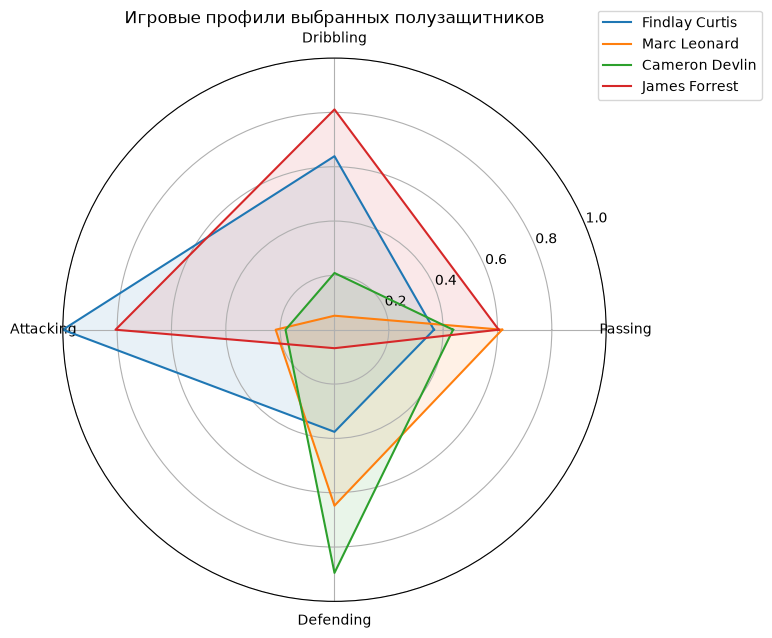

In [239]:
players = [
    'Findlay Curtis',
    'Marc Leonard',
    'Cameron Devlin',
    'James Forrest'
]

categories = [
    'Passing',
    'Dribbling',
    'Attacking',
    'Defending'
]

values = normalized_metrics.set_index('player_name').loc[
    players,
    profile_scores
].values

angles = np.linspace(
    0,
    2 * np.pi,
    len(categories),
    endpoint=False
)

angles = np.concatenate([angles, [angles[0]]])

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for player, player_values in zip(players, values):
    player_values = np.concatenate([player_values, [player_values[0]]])
    
    ax.plot(
        angles,
        player_values,
        label=player
    )
    
    ax.fill(
        angles,
        player_values,
        alpha=0.1
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

ax.set_ylim(0, 1)

plt.title('Игровые профили выбранных полузащитников')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

### Нападающие

In [240]:
attacking_metrics = [
    'goals_per90',
    'shots_total_per90',
    'shots_on_target_per90',
    'assists_per90',
    'big_chances_created_per90'
]

attackers[attacking_metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
goals_per90,64.0,0.324552,0.211555,0.000000,0.168309,0.313249,0.451442,0.920245
shots_total_per90,64.0,2.461574,0.798903,0.357143,1.897717,2.423030,2.942097,5.101744
shots_on_target_per90,64.0,0.947409,0.370839,0.000000,0.684021,0.926722,1.233278,1.857798
assists_per90,64.0,0.119985,0.102681,0.000000,0.000000,0.124566,0.176651,0.476190
big_chances_created_per90,64.0,0.207400,0.147563,0.000000,0.111451,0.194233,0.322707,0.552147


По распределениям видно, что показатели заметно различаются по степени разброса между нападающими. Для `goals_per90` среднее значение составляет **0.32**, медиана — **0.31**, при этом максимальное значение достигает **0.92**. Для `shots_total_per90` среднее равно **2.45**, медиана — **2.41**, а максимальное значение составляет **5.10**.

У `shots_on_target_per90` среднее значение составляет **0.94**, медиана — **0.92**, а у `assists_per90` — **0.12** и **0.12** соответственно. При этом у ассистов 25-й процентиль равен **0**, что говорит о наличии заметного количества игроков без ассистов. Для `big_chances_created_per90` среднее составляет **0.21**, медиана — **0.20**.

В целом наиболее заметный разброс между игроками наблюдается по количеству ударов и голам за 90 минут, тогда как ассисты имеют более низкие значения и большое количество нулевых наблюдений.

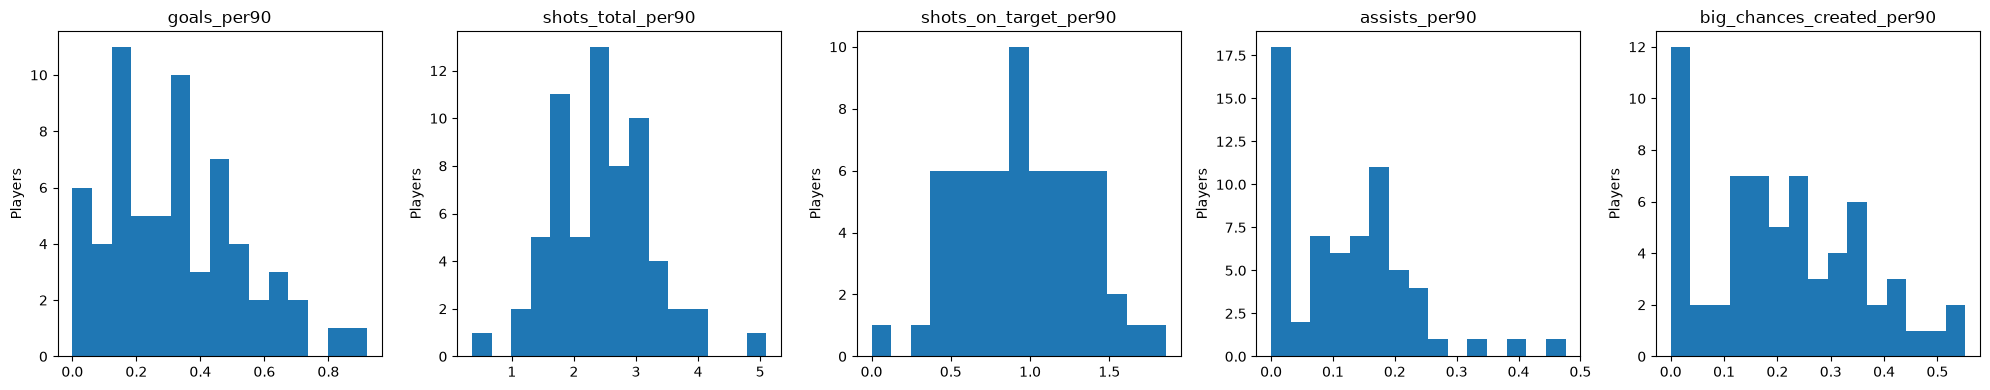

In [241]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, metric in zip(axes.flat, attacking_metrics):
    ax.hist(attackers[metric].dropna(), bins=15)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.set_ylabel('Players')
    
plt.tight_layout()

plt.show()

In [242]:
attackers[
    ['player_name', 'team_name', 'goals_per90', 'minutes']
].sort_values(
    'goals_per90',
    ascending=False
).head(10)

,player_name,team_name,goals_per90,minutes
200,Kelechi Promise Iheanacho,Celtic,0.920245,489
26,Ante Šuto,Hibernian,0.843091,427
350,Youssef Ramalho Chermiti,Rangers,0.684584,1972
106,Elie Youan,Hibernian,0.681818,660
172,Joe Hugill,Kilmarnock,0.659945,1091
344,Tyreece John-Jules,Kilmarnock,0.625543,1151
91,David Junior Hoilett,Hibernian,0.619266,436
28,Apostolos Stamatelopoulos,Motherwell,0.608108,888
216,Lawrence Shankland,Hearts,0.579011,2487
328,Tawanda Jethro Maswanhise,Motherwell,0.532730,2872


In [243]:
attackers[
    ['player_name', 'team_name', 'shots_total_per90', 'minutes']
].sort_values(
    'shots_total_per90',
    ascending=False
).head(10)

,player_name,team_name,shots_total_per90,minutes
179,Johnny Kenny,Celtic,5.101744,688
200,Kelechi Promise Iheanacho,Celtic,4.049080,489
91,David Junior Hoilett,Hibernian,3.922018,436
344,Tyreece John-Jules,Kilmarnock,3.675065,1151
350,Youssef Ramalho Chermiti,Rangers,3.559838,1972
170,Jesper Karlsson,Aberdeen,3.485670,1291
337,Tomáš Čvančara,Celtic,3.409091,528
106,Elie Youan,Hibernian,3.409091,660
150,Ivan Dolček,Dundee United,3.303571,1008
87,Danilo Pereira da Silva,Rangers,3.202847,562


In [244]:
attackers[
    ['player_name', 'team_name', 'shots_on_target_per90', 'minutes' ]
].sort_values(
    'shots_on_target_per90',
    ascending=False
).head(10)

,player_name,team_name,shots_on_target_per90,minutes
91,David Junior Hoilett,Hibernian,1.857798,436
350,Youssef Ramalho Chermiti,Rangers,1.643002,1972
331,Thibault Klidje,Hibernian,1.589674,736
344,Tyreece John-Jules,Kilmarnock,1.563858,1151
200,Kelechi Promise Iheanacho,Celtic,1.472393,489
179,Johnny Kenny,Celtic,1.438953,688
71,Cláudio Rafael Soares Braga,Hearts,1.395589,2902
49,Brian Graham,Falkirk,1.389961,777
299,Ryan Don Naderi,Rangers,1.369565,460
106,Elie Youan,Hibernian,1.363636,660


In [245]:
attackers[
    ['player_name', 'team_name',  'assists_per90', 'minutes']
].sort_values(
    'assists_per90',
    ascending=False
).head(10)

,player_name,team_name,assists_per90,minutes
65,Charlie Reilly,Dundee,0.476190,378
274,Oliver Antman,Rangers,0.387931,696
181,Jon Nouble,Livingston,0.323741,556
179,Johnny Kenny,Celtic,0.261628,688
121,Ethan Williams,Falkirk,0.252101,1071
271,Nikolaj Moller,Dundee United,0.229592,784
350,Youssef Ramalho Chermiti,Rangers,0.228195,1972
285,Regan Charles-Cook,Motherwell,0.223602,805
26,Ante Šuto,Hibernian,0.210773,427
91,David Junior Hoilett,Hibernian,0.206422,436


In [246]:
attackers[
    ['player_name', 'team_name', 'big_chances_created_per90', 'minutes']
].sort_values(
    'big_chances_created_per90',
    ascending=False
).head(10)

,player_name,team_name,big_chances_created_per90,minutes
200,Kelechi Promise Iheanacho,Celtic,0.552147,489
179,Johnny Kenny,Celtic,0.523256,688
181,Jon Nouble,Livingston,0.485612,556
65,Charlie Reilly,Dundee,0.476190,378
170,Jesper Karlsson,Aberdeen,0.418280,1291
91,David Junior Hoilett,Hibernian,0.412844,436
81,Daizen Maeda,Celtic,0.412407,2837
274,Oliver Antman,Rangers,0.387931,696
283,Pierre Landry Kabore,Hearts,0.383632,1173
316,Sebastian Tounekti,Celtic,0.356671,1514


По совокупности рейтингов выделяется **Kelechi Promise Iheanacho**: он занимает первое место по голам за 90 минут (**0.92**), второе по количеству ударов (**4.05**) и первое по созданным большим моментам (**0.55**). При этом его игровое время составляет только **489 минут**, поэтому такие значения за 90 минут требуют осторожной интерпретации.

**Johnny Kenny** также появляется сразу в нескольких рейтингах: он лидирует по количеству ударов (**5.10 за 90 минут**) и занимает второе место по созданным большим моментам (**0.52**). **David Junior Hoilett** показывает высокие значения по ударам (**3.92**) и ударам в створ (**1.86**), а **Youssef Ramalho Chermiti** входит в число лидеров по голам (**0.68**), ударам в створ (**1.64**) и ассистам (**0.23**).

По ассистам наиболее высокий показатель у **Charlie Reilly** — **0.48 за 90 минут**, а по созданию больших моментов среди лидеров также находятся **Jon Nouble** (**0.49**) и **Jesper Karlsson** (**0.42**). При этом часть игроков из верхних позиций имеет относительно небольшое игровое время, поэтому показатели за 90 минут необходимо учитывать вместе с количеством сыгранных минут.

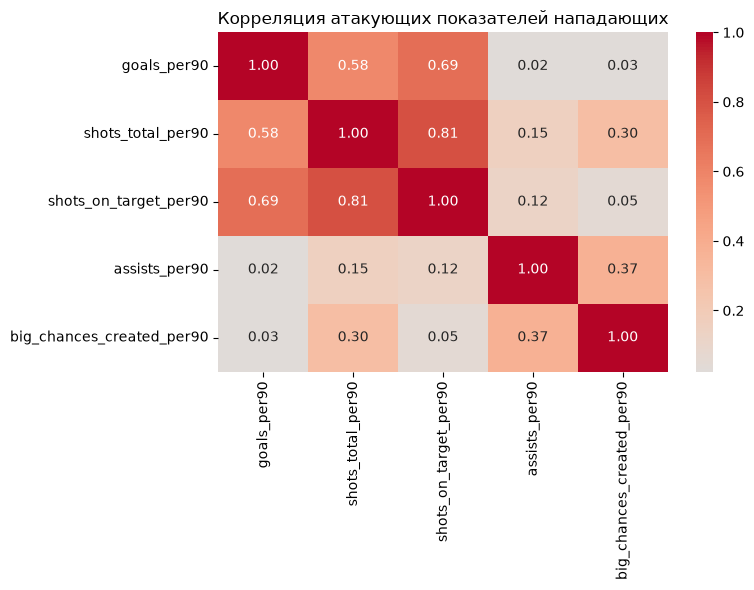

In [247]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    attackers[attacking_metrics].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Корреляция атакующих показателей нападающих')

plt.tight_layout()

plt.show()

По корреляционной матрице можно выделить две относительно самостоятельные группы показателей. Первая объединяет `goals_per90`, `shots_total_per90` и `shots_on_target_per90`, вторая — `assists_per90` и `big_chances_created_per90`. Между группами связи значительно слабее, чем внутри первой группы.

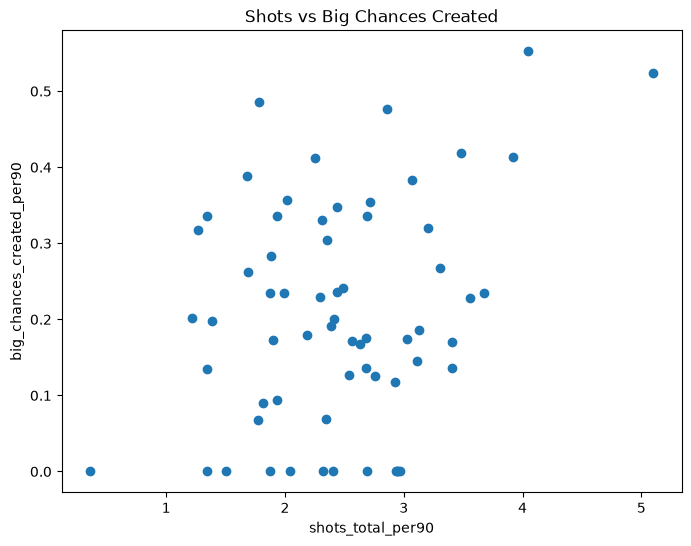

In [248]:
plt.figure(figsize=(8, 6))

plt.scatter(
    attackers['shots_total_per90'],
    attackers['big_chances_created_per90']
)

plt.xlabel('shots_total_per90')
plt.ylabel('big_chances_created_per90')
plt.title('Shots vs Big Chances Created')

plt.show()

На графике можно заметить отдельных игроков с необычным сочетанием показателей: при относительно небольшом количестве ударов они создают много больших моментов, тогда как у некоторых игроков большое количество ударов сочетается с низким значением `big_chances_created_per90`. Это дополнительно показывает, что эти показатели отражают разные стороны атакующих действий.

## Выводы

Анализ статистики игроков показал, что оценивать футболиста только по одной итоговой метрике недостаточно. Характер вклада сильно зависит от позиции и игрового профиля, поэтому показатели рассматривались отдельно для защитников, полузащитников и нападающих.

У защитников разные показатели описывают разные стороны оборонительной работы. Лидеры по отборам, перехватам, выигранным единоборствам и выносам в значительной степени не совпадают. Поэтому большое количество одного типа оборонительных действий не позволяет сделать вывод о полном профиле защитника.

Для полузащитников особенно заметно различие между объёмом работы и её направленностью. Количество передач в пересчёте на 90 минут слабо связано с количеством созданных моментов (r = 0,16), тогда как ключевые передачи значительно сильнее связаны с созданием моментов (r = 0,87). Это показывает, что сам объём пасов не является хорошим показателем атакующего вклада полузащитника.

Анализ дриблинга также показывает различие между активностью и эффективностью. Количество попыток обводки практически не связано с процентом успешных обводок (r = −0,04). При этом более высокая дриблинговая активность сопровождается большим количеством потерь мяча (r = 0,57). Таким образом, частые попытки обыгрыша соперника характеризуют стиль игры, но сами по себе не говорят о его эффективности.

Для сравнения полузащитников были сформированы четыре условных профиля: Passing, Dribbling, Attacking и Defending. Такой подход позволяет сравнивать игроков не по одной статистике, а по сочетанию нескольких характеристик. В данных сезона атакующий и дриблинговый профили имеют положительную связь (r = 0,65), тогда как атакующий и оборонительный профили связаны отрицательно (r = −0,40). При этом это не означает, что игрок должен однозначно относиться к одному типу: radar chart показывает, что полузащитники могут сочетать разные характеристики в различных пропорциях.

Для нападающих основными показателями результативности стали голы, удары, удары в створ и созданные моменты. При сравнении игроков использовались показатели на 90 минут, поскольку суммарные значения сильно зависят от игрового времени.

При этом per-90 метрики требуют осторожной интерпретации. Высокое значение показателя при небольшом количестве сыгранных минут может быть нестабильным и не отражать полноценный сезонный уровень игрока. Поэтому в рейтингах был установлен минимальный порог игрового времени в 360 минут. Например, высокий показатель голов на 90 минут у Kelechi Iheanacho следует рассматривать с учётом того, что он провёл на поле 489 минут.

В результате анализ показывает, что статистика игроков лучше работает не как единый рейтинг «лучших футболистов», а как способ сравнить различные типы игрового вклада. Для этого используются позиционная сегментация, показатели на 90 минут и составные профили игроков.